# GLP1R downsampled eda

Linear notebook for the pilot subset which builds the manifest, labels GLP1R+ cells, fits LASSO and XGBoost models, and exports summary tables and figures

In [1]:
import os
import re
import warnings
import hashlib
import itertools
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
from IPython.display import display
from scipy import sparse
from upsetplot import UpSet, from_contents
from xgboost import XGBClassifier

from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MaxAbsScaler

SEED = 42
CELLTYPE_CAP = 3000
TOP_CELLTYPES = 3
MIN_TOTAL = 1000
MIN_POS = 50
POS_CAP = 3000
NEG_POS_RATIO = 2
N_REPEATS = 5
STABLE_FREQ_THRESHOLD = 0.6
XGB_TOP_K = 100
PERM_N_REPEATS = 20

XGB_BASE_PARAMS = {
    "n_estimators": 400,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "n_jobs": -1
}

np.random.seed(SEED)


In [2]:
PROJECT_ROOT = Path("/Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj")
DATA_DIR = PROJECT_ROOT/"data"
META_DIR = PROJECT_ROOT/"metadata"
ANALYSIS_DIR = PROJECT_ROOT/"analysis"
RESULTS_DIR = ANALYSIS_DIR/"results"
FIG_DIR = ANALYSIS_DIR/"figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str((ANALYSIS_DIR/".mplconfig").resolve()))
(ANALYSIS_DIR/".mplconfig").mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] ="DejaVu Sans"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR:", FIG_DIR)


PROJECT_ROOT: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj
RESULTS_DIR: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results
FIG_DIR: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures


## Helper functions


In [3]:
def stable_seed(seed, key):
    digest = hashlib.md5(str(key).encode("utf-8")).hexdigest()
    return seed + int(digest[:8], 16) % 1_000_000


def save_fig(fig, stem):
    png = FIG_DIR/f"{stem}.png"
    svg = FIG_DIR/f"{stem}.svg"
    fig.savefig(png, bbox_inches="tight", dpi=300)
    fig.savefig(svg, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", svg)


def canonicalize_id(value):
    if isinstance(value, (bytes, bytearray, np.bytes_)):
        text = value.decode("utf-8")
    else:
        text = str(value)

    text = text.strip()
    if text.startswith("b'") and text.endswith("'"):
        text = text[2:-1]
    elif text.startswith('b"') and text.endswith('"'):
        text = text[2:-1]
    return text


def normalize_index(values):
    normalized_values = []
    for value in values:
        normalized_values.append(canonicalize_id(value))
    return pd.Index(normalized_values)


In [4]:
def allocate_by_day(day_counts, target):
    if target >= int(day_counts.sum()):
        return day_counts.copy()

    proportions = day_counts/day_counts.sum()
    raw = proportions*target
    alloc = np.floor(raw).astype(int)
    alloc = np.minimum(alloc, day_counts)

    remainder = int(target - alloc.sum())
    if remainder > 0:
        frac = (raw - alloc).sort_values(ascending=False)
        order = frac.index.tolist()
        i = 0
        while remainder > 0:
            day = order[i % len(order)]
            if alloc[day] < day_counts[day]:
                alloc[day] +=1
                remainder -= 1
            i += 1

    if remainder > 0:
        spare = (day_counts - alloc).sort_values(ascending=False)
        for day, room in spare.items():
            if room <= 0:
                continue
            take = min(int(room), remainder)
            alloc[day] += take
            remainder -= take
            if remainder == 0:
                break

    return alloc


def downsample_within_celltype(group, cap, seed):
    if len(group) <= cap:
        return group

    group_key = str(group["celltype_update"].iloc[0])
    day_counts = group["day"].value_counts()
    alloc = allocate_by_day(day_counts, cap)

    picked = []
    for i, (day, n_take) in enumerate(alloc.items()):
        day_group = group[group["day"] == day]
        if n_take >= len(day_group):
            picked.append(day_group)
        elif n_take > 0:
            picked.append(
                day_group.sample(
                    n=n_take,
                    random_state=stable_seed(seed + i, group_key)
                )
            )

    out = pd.concat(picked, axis=0)
    if len(out) < cap:
        remainder = group.loc[~group.index.isin(out.index)]
        n_add = min(cap - len(out), len(remainder))
        if n_add > 0:
            extra = remainder.sample(
                n=n_add,
                random_state=stable_seed(seed, f"topup|{group_key}")
            )
            out = pd.concat([out, extra], axis=0)
    elif len(out) > cap:
        out = out.sample(n=cap, random_state=stable_seed(seed, f"trim|{group_key}"))

    return out


def assign_quantile_bins(series, q=5):
    if series.nunique(dropna=True)<= 1:
        return pd.Series(["0"]*len(series), index=series.index)

    ranks = series.rank(method="first")
    bins = pd.qcut(ranks, q=min(q, series.nunique()), labels=False, duplicates="drop")
    return bins.astype(str)


def add_match_strata(df):
    out = df.copy()
    out["umi_bin"] = assign_quantile_bins(out["UMI_count"].fillna(out["UMI_count"].median()))
    out["gene_bin"] = assign_quantile_bins(out["gene_count"].fillna(out["gene_count"].median()))
    out["match_stratum"] = (
        out["day"].astype(str)
        + "|"
        + out["experimental_id"].astype(str)
        + "|"
        + out["umi_bin"].astype(str)
        + "|"
        + out["gene_bin"].astype(str)
    )
    return out


def matched_negative_sample(pos_df, neg_df, ratio, seed):
    desired = min(len(neg_df), int(len(pos_df)*ratio))
    if desired <= 0:
        return neg_df.iloc[[]]

    chosen_idx = []
    for i, (stratum, n_pos_stratum) in enumerate(pos_df["match_stratum"].value_counts().items()):
        pool = neg_df[neg_df["match_stratum"] == stratum]
        if len(pool) == 0:
            continue
        want = min(len(pool), int(np.ceil(n_pos_stratum*ratio)))
        picked = pool.sample(n=want, random_state=stable_seed(seed + i, f"{stratum}|primary"))
        chosen_idx.extend(picked.index.tolist())

    sampled = neg_df.loc[list(dict.fromkeys(chosen_idx))]

    if len(sampled) < desired:
        remainder = neg_df.loc[~neg_df.index.isin(sampled.index)]
        if len(remainder) > 0:
            add_n = min(desired - len(sampled), len(remainder))
            extra = remainder.sample(n=add_n, random_state=stable_seed(seed, "global_fill"))
            sampled = pd.concat([sampled, extra], axis=0)

    if len(sampled) > desired:
        sampled = sampled.sample(n=desired, random_state=stable_seed(seed, "trim_to_desired"))

    return sampled


In [5]:
_TRAILING_NUMERIC_SUFFIX = re.compile(r"-\d+$")


def to_lookup_id(value, lookup_keys, max_strip=4):
    text = canonicalize_id(value)
    if text in lookup_keys:
        return text

    stripped = text
    for _ in range(max_strip):
        next_value = _TRAILING_NUMERIC_SUFFIX.sub("", stripped)
        if next_value == stripped:
            break
        stripped = next_value
        if stripped in lookup_keys:
            return stripped
    return text


def resolve_glp1r_index(adata_obj, gene_table):
    var_names = normalize_index(adata_obj.var_names)
    glp1r_ids = set(
        gene_table.loc[
            gene_table["gene_short_name"].astype(str).str.lower() == "glp1r",
            "gene_id"
        ]
        .astype(str)
        .map(canonicalize_id)
    )

    direct_mask = var_names.isin(glp1r_ids) | (var_names.str.lower() == "glp1r")
    if int(direct_mask.sum()) == 1:
        idx = int(np.where(direct_mask)[0][0])
        return idx, str(var_names[idx])

    for col in ["gene_short_name", "gene_symbols", "feature_name", "gene_id"]:
        if col not in adata_obj.var.columns:
            continue
        values = adata_obj.var[col].map(canonicalize_id).str.lower()
        mask = values == "glp1r"
        if int(mask.sum()) == 1:
            idx = int(np.where(mask.values)[0][0])
            return idx, str(var_names[idx])

    raise ValueError("Could not resolve a unique Glp1r column in adata.var")


def fetch_expression_for_cells(cells_df, data_dir):
    parts = []
    order = []
    temp = cells_df.reset_index(drop=True).copy()
    temp["_order"] = np.arange(len(temp))

    for file_name, sub in temp.groupby("h5ad_file", sort=False):
        adata_obj = ad.read_h5ad(str(data_dir/file_name), backed="r")
        rows = sub["row_idx"].astype(int).to_numpy()
        if "counts" in adata_obj.layers:
            X = adata_obj.layers["counts"][rows, :]
        elif "raw_counts" in adata_obj.layers:
            X = adata_obj.layers["raw_counts"][rows, :]
        else:
            X = adata_obj.X[rows, :]
        if sparse.issparse(X):
            X = X.tocsr()
        else:
            X = sparse.csr_matrix(np.asarray(X))
        parts.append(X)
        order.append(sub["_order"].to_numpy())
        if getattr(adata_obj, "isbacked", False):
            adata_obj.file.close()

    X_all = sparse.vstack(parts).tocsr()
    return X_all[np.argsort(np.concatenate(order))]


In [6]:
def prepare_modeling_data_for_celltype(ct, manifest_df, data_dir, glp1r_idx, gene_labels_arr, seed, min_pos, pos_cap, neg_pos_ratio):
    ct_df = manifest_df[manifest_df["celltype_update"] == ct].copy()
    pos = ct_df[ct_df["glp1r_pos"] == 1].copy()
    neg = ct_df[ct_df["glp1r_pos"] == 0].copy()

    if len(pos) > pos_cap:
        pos = pos.sample(pos_cap, random_state=stable_seed(seed, f"pos_cap|{ct}"))

    pool = add_match_strata(pd.concat([pos, neg], axis=0))
    pos = pool.loc[pos.index]
    neg = pool.loc[neg.index]

    neg_sample = matched_negative_sample(
        pos,
        neg,
        ratio=neg_pos_ratio,
        seed=stable_seed(seed, f"neg_match|{ct}")
    )
    model_cells = pd.concat([pos, neg_sample], axis=0).sample(
        frac=1.0,
        random_state=stable_seed(seed, f"shuffle|{ct}")
    )
    y = model_cells["glp1r_pos"].astype(int).to_numpy()

    X = fetch_expression_for_cells(model_cells[["obs_name", "h5ad_file", "row_idx"]], data_dir)
    X = X.tocsr(copy=True)
    X.data = np.log1p(X.data)

    min_detect = max(1, int(np.ceil(0.01*X.shape[0])))
    keep = np.asarray((X > 0).sum(axis=0)).ravel() >= min_detect
    keep[glp1r_idx] = False

    X = X[:, keep]

    pos_mean = np.asarray(X[y == 1].mean(axis=0)).ravel()
    neg_mean = np.asarray(X[y == 0].mean(axis=0)).ravel()

    return {"celltype_update": ct,
            "X": X,
            "y": y,
            "genes_kept": pd.Index(gene_labels_arr[keep]).astype(str),
            "expr_diff_sign": np.sign(pos_mean - neg_mean),
            "n_pos": int((y == 1).sum()),
            "n_neg": int((y == 0).sum()),
            "baseline_prevalence": float(y.mean()),
            "n_genes_after_filter": int(X.shape[1])}


In [7]:
def fit_lasso_repeated(X, y, seeds):
    metric_rows = []
    coef_list = []

    for seed in seeds:
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        model_cv = make_pipeline(
            MaxAbsScaler(),
            LogisticRegressionCV(
                Cs=np.logspace(-3, 1, 20),
                cv=inner_cv,
                penalty="l1",
                solver="saga",
                class_weight="balanced",
                scoring="average_precision",
                max_iter=5000,
                random_state=seed,
                n_jobs=-1,
                refit=True
            )
        )

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            model_cv.fit(X, y)
        converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)

        best_c = float(np.ravel(model_cv.named_steps["logisticregressioncv"].C_)[0])
        base_model = make_pipeline(
            MaxAbsScaler(),
            LogisticRegression(
                C=best_c,
                penalty="l1",
                solver="saga",
                class_weight="balanced",
                max_iter=5000,
                random_state=seed,
                n_jobs=-1
            )
        )

        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        prob = cross_val_predict(base_model, X, y, cv=outer_cv, method="predict_proba", n_jobs=-1)[:, 1]
        auroc = roc_auc_score(y, prob)
        auprc = average_precision_score(y, prob)

        base_model.fit(X, y)
        coef_list.append(base_model.named_steps["logisticregression"].coef_.ravel())

        metric_rows.append({"repeat_seed": seed,
                            "auroc": float(auroc),
                            "auprc": float(auprc),
                            "best_c": best_c,
                            "converged": bool(converged)})

    return pd.DataFrame(metric_rows), np.vstack(coef_list)


In [8]:
def fit_xgb_repeated(X, y, seeds, base_params):
    metric_rows = []

    for seed in seeds:
        params = dict(base_params)
        params["random_state"] = seed
        model = XGBClassifier(**params)

        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        prob = cross_val_predict(model, X, y, cv=outer_cv, method="predict_proba", n_jobs=1)[:, 1]

        metric_rows.append({"repeat_seed": seed,
                            "auroc": float(roc_auc_score(y, prob)),
                            "auprc": float(average_precision_score(y, prob)),
                            "converged": True})

    return pd.DataFrame(metric_rows)


def compute_xgb_permutation_scores(X, y, genes, seeds, base_params, top_k, perm_repeats):
    rows = []

    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
        params = dict(base_params)
        params["random_state"] = seed
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        X_test_dense = X_test.toarray() if sparse.issparse(X_test) else np.asarray(X_test)
        perm = permutation_importance(model, X_test_dense, y_test, scoring="average_precision", n_repeats=perm_repeats, random_state=seed, n_jobs=-1)

        means = perm.importances_mean.astype(float)
        stds = perm.importances_std.astype(float)
        top_idx = set(np.argsort(-means)[: min(top_k, len(means))].tolist())

        for i, gene in enumerate(genes):
            rows.append({"repeat_seed": int(seed),
                         "gene": str(gene),
                         "perm_importance_mean": float(means[i]),
                         "perm_importance_sd": float(stds[i]),
                         "selected_topk": bool(i in top_idx)})

    rep = pd.DataFrame(rows)
    agg = (
        rep.groupby("gene", as_index=False)
        .agg(
            perm_importance_median=("perm_importance_mean", "median"),
            perm_importance_mean=("perm_importance_mean", "mean"),
            perm_importance_sd=("perm_importance_mean", lambda s: float(np.std(s, ddof=0))),
            selection_freq=("selected_topk", "mean")
        )
    )
    return rep, agg


## Build the downsampled manifest (skip if have data)


In [ ]:
meta_cols = [
    "cell_id",
    "day",
    "experimental_id",
    "UMI_count",
    "gene_count",
    "major_trajectory",
    "celltype_update",
    "UMAP_2d_1",
    "UMAP_2d_2"
]

meta_df = next(iter(pyreadr.read_r(str(META_DIR/"df_cell.rds")).values()))[meta_cols].copy()
obs_map = pd.read_csv(DATA_DIR/"df_cell.csv", usecols=["Unnamed: 0", "cell_id"])
obs_map = obs_map.rename(columns={"Unnamed: 0": "obs_name"})

meta_obs = meta_df.merge(obs_map, on="cell_id", how="inner", validate="one_to_one")

manifest = pd.concat(
    [
        downsample_within_celltype(group, CELLTYPE_CAP, stable_seed(SEED, celltype))
        for celltype, group in meta_obs.groupby("celltype_update", sort=False)
    ],
    axis=0
).reset_index(drop=True)

manifest.to_csv(RESULTS_DIR/"downsample_manifest.csv", index=False)
print("Saved:", RESULTS_DIR/"downsample_manifest.csv")

summary = (
    manifest.groupby("celltype_update").size().rename("n_downsampled").to_frame()
    .join(meta_obs.groupby("celltype_update").size().rename("n_original"))
    .assign(frac=lambda df: df["n_downsampled"]/df["n_original"])
    .sort_values("n_original", ascending=False)
)

print("Downsampled cells:", len(manifest))
display(summary.head(10))


## Attach h5ad locations and GLP1R labels (skip if have data)


In [ ]:
gene_table = pd.read_csv(DATA_DIR/"df_gene.csv")
h5ad_files = sorted(DATA_DIR.glob("adata_JAX_dataset_*.h5ad"))

selected_cells = manifest[["obs_name", "cell_id"]].drop_duplicates().reset_index(drop=True)
selected_lookup = pd.Index(selected_cells["cell_id"].map(canonicalize_id))
lookup_keys = set(selected_lookup.tolist())

loc_records = []
label_records = []
match_counts = []
reference_var_names = None
gene_labels = None
glp1r_index = None
first_obs_preview = None

for path in h5ad_files:
    print("Indexing:", path.name)
    adata_obj = ad.read_h5ad(str(path), backed="r")
    obs_names = normalize_index(adata_obj.obs_names)
    if first_obs_preview is None:
        first_obs_preview = obs_names[:5].tolist()

    obs_lookup_values = []
    for obs_name in obs_names:
        obs_lookup_values.append(to_lookup_id(obs_name, lookup_keys))
    obs_lookup = pd.Index(obs_lookup_values)

    row_idx = obs_lookup.get_indexer(selected_lookup)
    keep = row_idx >= 0
    match_counts.append({"h5ad_file": path.name, "n_selected_cells": int(keep.sum())})

    if not keep.any():
        if getattr(adata_obj, "isbacked", False):
            adata_obj.file.close()
        continue

    matched_obs = selected_cells.loc[keep, "obs_name"].to_numpy()
    loc_records.append(
        pd.DataFrame({"obs_name": matched_obs,
                      "h5ad_file": path.name,
                      "row_idx": row_idx[keep].astype(int)})
    )

    this_var = normalize_index(adata_obj.var_names)
    if reference_var_names is None:
        reference_var_names = this_var
        glp1r_index, matched_var = resolve_glp1r_index(adata_obj, gene_table)

        fallback = pd.Series(this_var.to_numpy(), index=this_var)
        if "gene_short_name" in adata_obj.var.columns:
            label_series = adata_obj.var["gene_short_name"].map(canonicalize_id)
            label_series.index = this_var
        elif "gene_symbols" in adata_obj.var.columns:
            label_series = adata_obj.var["gene_symbols"].map(canonicalize_id)
            label_series.index = this_var
        else:
            name_map = (
                gene_table.assign(gene_id=gene_table["gene_id"].astype(str).map(canonicalize_id))
                .set_index("gene_id")["gene_short_name"]
            )
            label_series = pd.Series(this_var.to_numpy(), index=this_var).map(name_map).fillna(fallback)

        label_series = label_series.astype(str).replace({"nan": "", "None": ""})
        fallback_names = fallback.astype(str)
        unique_labels = []
        seen = {}
        for label, default in zip(label_series, fallback_names):
            base = label if label else default
            if base in seen:
                seen[base] += 1
                candidate = f"{base}|{default}"
                if candidate in seen:
                    candidate = f"{candidate}_{seen[base]}"
                unique_labels.append(candidate)
                seen[candidate] = 1
            else:
                seen[base] = 1
                unique_labels.append(base)
        gene_labels = np.array(unique_labels, dtype=object)

        print(f"  Glp1r column index: {glp1r_index} ({matched_var})")

    if "counts" in adata_obj.layers:
        glp1r_expr = adata_obj.layers["counts"][row_idx[keep], glp1r_index]
    elif "raw_counts" in adata_obj.layers:
        glp1r_expr = adata_obj.layers["raw_counts"][row_idx[keep], glp1r_index]
    else:
        glp1r_expr = adata_obj.X[row_idx[keep], glp1r_index]

    if sparse.issparse(glp1r_expr):
        glp1r_expr = np.asarray(glp1r_expr.toarray()).ravel()
    else:
        glp1r_expr = np.asarray(glp1r_expr).ravel()

    label_records.append(
        pd.DataFrame({"obs_name": matched_obs,
                      "glp1r_expr": glp1r_expr,
                      "glp1r_pos": (glp1r_expr > 0).astype(int)})
    )
    if getattr(adata_obj, "isbacked", False):
        adata_obj.file.close()

loc_df = pd.concat(loc_records, axis=0, ignore_index=True).drop_duplicates(subset=["obs_name"])
lab_df = pd.concat(label_records, axis=0, ignore_index=True).drop_duplicates(subset=["obs_name"])

manifest = (
    manifest.merge(loc_df, on="obs_name", how="inner", validate="one_to_one")
    .merge(lab_df, on="obs_name", how="inner", validate="one_to_one")
)

manifest.to_csv(RESULTS_DIR/"downsample_manifest.csv", index=False)
print("Saved:", RESULTS_DIR/"downsample_manifest.csv")
print("GLP1R+ prevalence in pilot subset:", round(manifest["glp1r_pos"].mean(), 4))
display(pd.DataFrame(match_counts))


## Rank the top GLP1R-enriched cell types


In [9]:
#Rebuild
manifest = pd.read_csv(RESULTS_DIR/"downsample_manifest.csv")

gene_table = pd.read_csv(DATA_DIR/"df_gene.csv")
reference_h5ad = DATA_DIR/manifest["h5ad_file"].dropna().iat[0]
adata_obj = ad.read_h5ad(str(reference_h5ad), backed="r")

In [10]:
reference_var_names = normalize_index(adata_obj.var_names)
glp1r_index, matched_var = resolve_glp1r_index(adata_obj, gene_table)

fallback = pd.Series(reference_var_names.to_numpy(), index=reference_var_names)
if "gene_short_name" in adata_obj.var.columns:
    label_series = adata_obj.var["gene_short_name"].map(canonicalize_id)
    label_series.index = reference_var_names
elif "gene_symbols" in adata_obj.var.columns:
    label_series = adata_obj.var["gene_symbols"].map(canonicalize_id)
    label_series.index = reference_var_names
else:
    name_map = (
        gene_table.assign(gene_id=gene_table["gene_id"].astype(str).map(canonicalize_id))
        .set_index("gene_id")["gene_short_name"]
    )
    label_series = pd.Series(reference_var_names.to_numpy(), index=reference_var_names).map(name_map).fillna(fallback)

label_series = label_series.astype(str).replace({"nan": "", "None": ""})
fallback_names = fallback.astype(str)
unique_labels = []
seen = {}
for label, default in zip(label_series, fallback_names):
    base = label if label else default
    if base in seen:
        seen[base] += 1
        candidate = f"{base}|{default}"
        if candidate in seen:
            candidate = f"{candidate}_{seen[base]}"
        unique_labels.append(candidate)
        seen[candidate] = 1
    else:
        seen[base] = 1
        unique_labels.append(base)
gene_labels = np.array(unique_labels, dtype=object)

if getattr(adata_obj, "isbacked", False):
    adata_obj.file.close()

print(f"Loaded: {RESULTS_DIR/'downsample_manifest.csv'}")
print(f"Reference h5ad: {reference_h5ad.name}")
print(f"Glp1r column index: {glp1r_index} ({matched_var})")

Loaded: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/downsample_manifest.csv
Reference h5ad: adata_JAX_dataset_1.h5ad
Glp1r column index: 22471 (ENSMUSG00000024027)


In [11]:
ct_stats = (
    manifest.groupby("celltype_update")
    .agg(
        n_total=("obs_name", "size"),
        n_glp1r_pos=("glp1r_pos", "sum"),
        major_trajectory=("major_trajectory", lambda x: x.mode().iat[0] if len(x.mode()) else x.iat[0])
    )
    .reset_index()
)
ct_stats["glp1r_frac"] = ct_stats["n_glp1r_pos"]/ct_stats["n_total"]

eligible = ct_stats[(ct_stats["n_total"] >= MIN_TOTAL) & (ct_stats["n_glp1r_pos"] >= MIN_POS)].copy()
eligible = eligible.sort_values("glp1r_frac", ascending=False).reset_index(drop=True)

top_celltypes = eligible.head(TOP_CELLTYPES).copy()
top_celltypes["rank"] = np.arange(1, len(top_celltypes) + 1)

top_celltypes[
    ["rank", "celltype_update", "major_trajectory", "n_total", "n_glp1r_pos", "glp1r_frac"]
].to_csv(RESULTS_DIR/"top_celltypes.csv", index=False)

print("Saved:", RESULTS_DIR/"top_celltypes.csv")
display(top_celltypes[["rank", "celltype_update", "major_trajectory", "n_total", "n_glp1r_pos", "glp1r_frac"]])


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/top_celltypes.csv


,rank,celltype_update,major_trajectory,n_total,n_glp1r_pos,glp1r_frac
0,1,Glomerular endothelial cells,Endothelium,3000,418,0.139333
1,2,Lung cells (Eln+),Lung_and_airway,3000,240,0.080000
2,3,Pancreatic islets,Eye_and_other,1323,57,0.043084


## Figures 1-2


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig1_glp1r_landscape.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig1_glp1r_landscape.svg


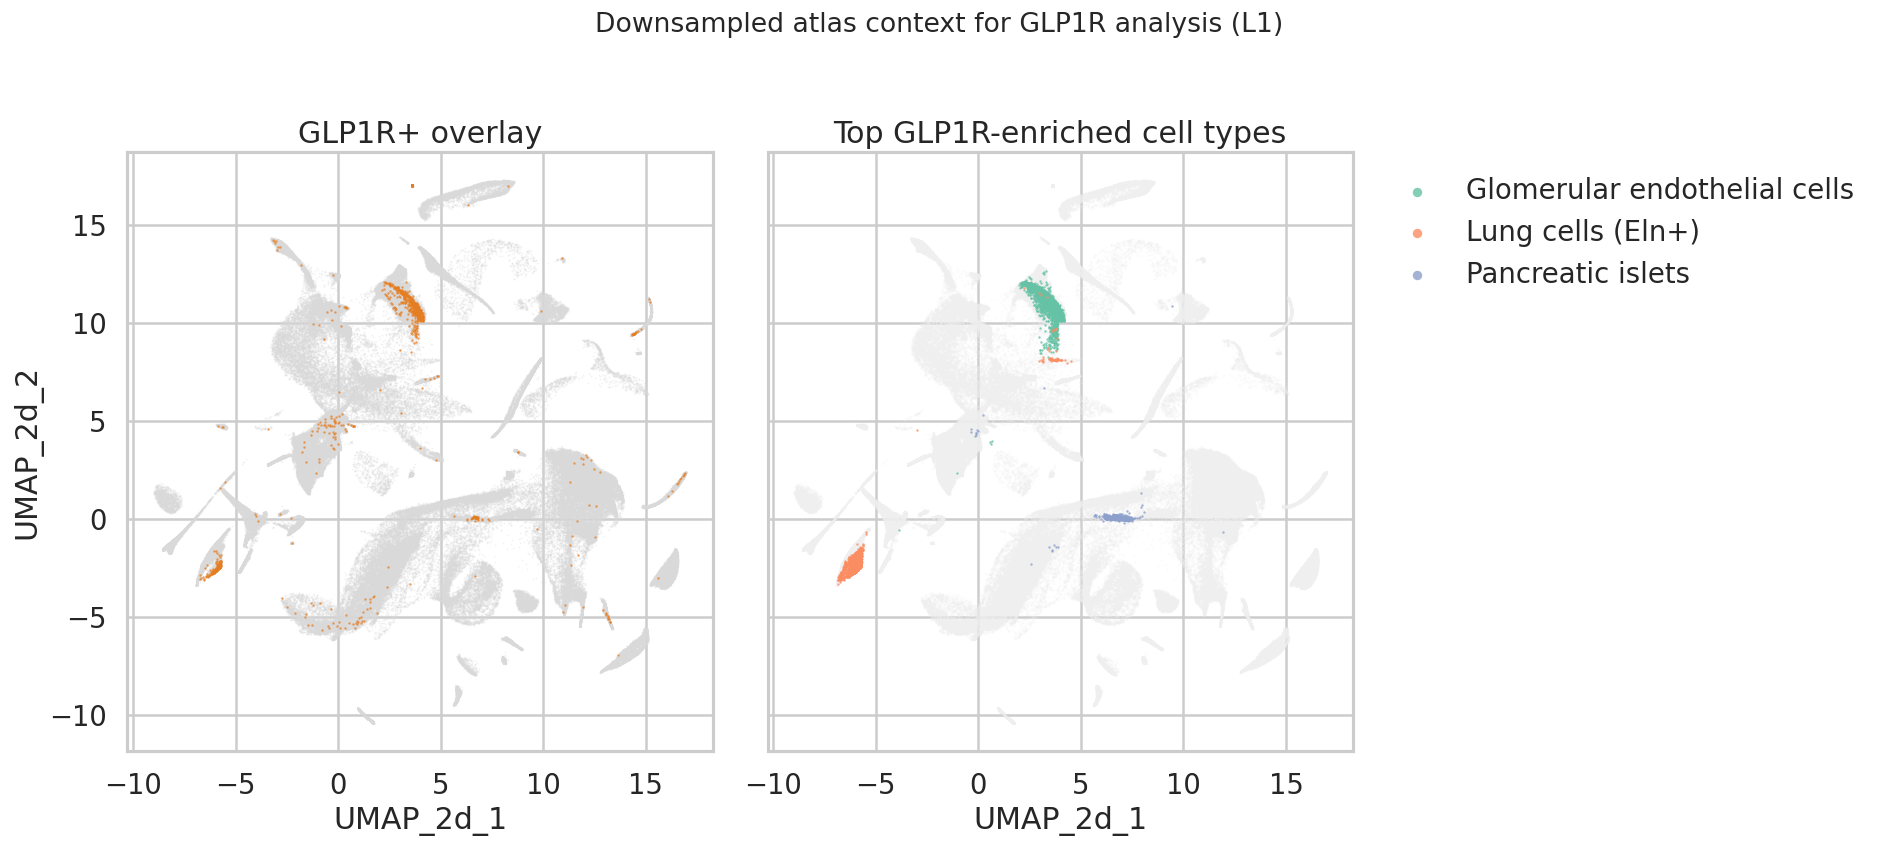

In [12]:
plot_df = manifest.dropna(subset=["UMAP_2d_1", "UMAP_2d_2"]).copy()
selected_ct = top_celltypes["celltype_update"].tolist()

background_cap = 220_000
if len(plot_df) > background_cap:
    background = plot_df.sample(background_cap, random_state=SEED)
else:
    background = plot_df

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

axes[0].scatter(background["UMAP_2d_1"], background["UMAP_2d_2"], s=1, c="#d9d9d9", alpha=0.35, linewidths=0)
pos = plot_df[plot_df["glp1r_pos"] == 1]
axes[0].scatter(pos["UMAP_2d_1"], pos["UMAP_2d_2"], s=2, c="#e67e22", alpha=0.75, linewidths=0)
axes[0].set_title("GLP1R+ overlay")
axes[0].set_xlabel("UMAP_2d_1")
axes[0].set_ylabel("UMAP_2d_2")

axes[1].scatter(background["UMAP_2d_1"], background["UMAP_2d_2"], s=1, c="#efefef", alpha=0.3, linewidths=0)
palette = sns.color_palette("Set2", n_colors=len(selected_ct))
for color, ct in zip(palette, selected_ct):
    sub = plot_df[plot_df["celltype_update"] == ct]
    axes[1].scatter(sub["UMAP_2d_1"], sub["UMAP_2d_2"], s=2, color=color, alpha=0.8, linewidths=0, label=ct)
axes[1].set_title("Top GLP1R-enriched cell types")
axes[1].set_xlabel("UMAP_2d_1")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, markerscale=4)

fig.suptitle("Downsampled atlas context for GLP1R analysis (L1)", y=1.02, fontsize=16)
plt.tight_layout()
save_fig(fig, "Fig1_glp1r_landscape")
plt.show()


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig2_top_celltypes_bar.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig2_top_celltypes_bar.svg


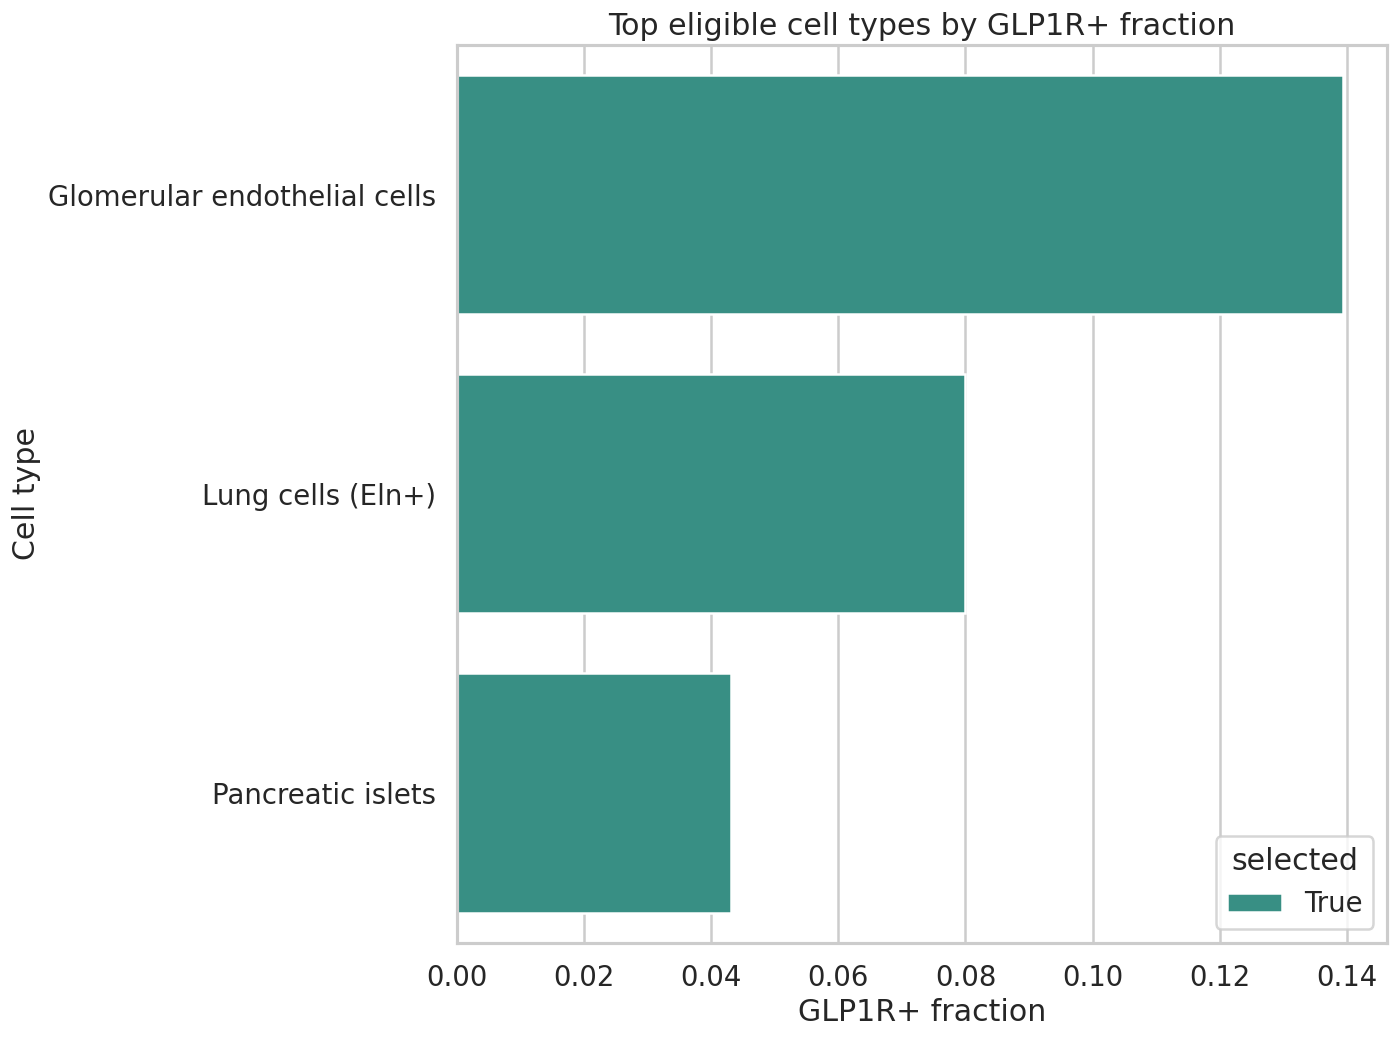

In [13]:
rank_plot = eligible.head(20).copy()
rank_plot["selected"] = rank_plot["celltype_update"].isin(top_celltypes["celltype_update"])

fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(
    data=rank_plot,
    y="celltype_update",
    x="glp1r_frac",
    hue="selected",
    dodge=False,
    palette={True: "#2a9d8f", False: "#bdbdbd"},
    ax=ax
)
ax.set_xlabel("GLP1R+ fraction")
ax.set_ylabel("Cell type")
ax.set_title("Top eligible cell types by GLP1R+ fraction")

plt.tight_layout()
save_fig(fig, "Fig2_top_celltypes_bar")
plt.show()


## Prepare modeling matrices


In [14]:
repeat_seeds = []
for i in range(N_REPEATS):
    repeat_seeds.append(SEED + i)
selected_ct = top_celltypes["celltype_update"].tolist()

prepared_data = {}
prep_rows = []

for ct in selected_ct:
    print("Preparing:", ct)
    bundle = prepare_modeling_data_for_celltype(
        ct=ct,
        manifest_df=manifest,
        data_dir=DATA_DIR,
        glp1r_idx=glp1r_index,
        gene_labels_arr=gene_labels,
        seed=SEED,
        min_pos=MIN_POS,
        pos_cap=POS_CAP,
        neg_pos_ratio=NEG_POS_RATIO
    )
    prepared_data[ct] = bundle
    prep_rows.append({"celltype_update": ct,
                      "n_pos": bundle["n_pos"],
                      "n_neg": bundle["n_neg"],
                      "baseline_prevalence": bundle["baseline_prevalence"],
                      "n_genes_after_filter": bundle["n_genes_after_filter"]})

prep_summary = pd.DataFrame(prep_rows)
display(prep_summary)


Preparing: Glomerular endothelial cells
Preparing: Lung cells (Eln+)
Preparing: Pancreatic islets


,celltype_update,n_pos,n_neg,baseline_prevalence,n_genes_after_filter
0,Glomerular endothelial cells,418,836,0.333333,11550
1,Lung cells (Eln+),240,480,0.333333,12535
2,Pancreatic islets,57,114,0.333333,13240


## Repeated LASSO models


In [15]:
metric_summary_rows = []
metric_repeat_rows = []
coef_tables = []

for ct in selected_ct:
    print("Modeling:", ct)
    bundle = prepared_data[ct]
    metrics_repeat, coef_arr = fit_lasso_repeated(bundle["X"], bundle["y"], repeat_seeds)

    metrics_repeat["celltype_update"] = ct
    metrics_repeat["n_pos"] = bundle["n_pos"]
    metrics_repeat["n_neg"] = bundle["n_neg"]
    metrics_repeat["baseline_prevalence"] = bundle["baseline_prevalence"]
    metrics_repeat["n_genes_after_filter"] = bundle["n_genes_after_filter"]
    metric_repeat_rows.append(metrics_repeat)

    coef_df = pd.DataFrame({"celltype_update": ct,
                            "gene": bundle["genes_kept"].astype(str),
                            "coef_median": np.median(coef_arr, axis=0),
                            "abs_coef": np.median(np.abs(coef_arr), axis=0),
                            "selection_freq": (coef_arr != 0).mean(axis=0)})
    coef_df["direction"] = np.where(
        coef_df["coef_median"] > 0,
        "positive",
        np.where(coef_df["coef_median"] < 0, "negative", "zero")
    )
    coef_df["selected_stable"] = coef_df["selection_freq"] >= STABLE_FREQ_THRESHOLD
    coef_tables.append(coef_df)

    metric_summary_rows.append({"celltype_update": ct,
                                "baseline_prevalence": bundle["baseline_prevalence"],
                                "n_pos": bundle["n_pos"],
                                "n_neg": bundle["n_neg"],
                                "n_genes_after_filter": bundle["n_genes_after_filter"],
                                "auroc": float(metrics_repeat["auroc"].mean()),
                                "auprc": float(metrics_repeat["auprc"].mean()),
                                "auroc_sd": float(metrics_repeat["auroc"].std(ddof=0)),
                                "auprc_sd": float(metrics_repeat["auprc"].std(ddof=0)),
                                "all_repeats_converged": bool(metrics_repeat["converged"].all())})

model_metrics = pd.DataFrame(metric_summary_rows)
model_metrics_repeat = pd.concat(metric_repeat_rows, axis=0, ignore_index=True)
lasso_coef = pd.concat(coef_tables, axis=0, ignore_index=True)

model_metrics.to_csv(RESULTS_DIR/"model_metrics.csv", index=False)
model_metrics_repeat.to_csv(RESULTS_DIR/"model_metrics_repeats.csv", index=False)
lasso_coef.to_csv(RESULTS_DIR/"lasso_coefficients.csv", index=False)

print("Saved:", RESULTS_DIR/"model_metrics.csv")
print("Saved:", RESULTS_DIR/"model_metrics_repeats.csv")
print("Saved:", RESULTS_DIR/"lasso_coefficients.csv")
display(model_metrics)


Modeling: Glomerular endothelial cells


/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/ryannayebi/miniforge3/en

Modeling: Lung cells (Eln+)


/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/ryannayebi/miniforge3/en

Modeling: Pancreatic islets


/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/ryannayebi/miniforge3/en

Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/model_metrics.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/model_metrics_repeats.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/lasso_coefficients.csv


,celltype_update,baseline_prevalence,n_pos,n_neg,n_genes_after_filter,auroc,auprc,auroc_sd,auprc_sd,all_repeats_converged
0,Glomerular endothelial cells,0.333333,418,836,11550,0.621801,0.433896,0.010258,0.008701,False
1,Lung cells (Eln+),0.333333,240,480,12535,0.728826,0.565600,0.018075,0.026108,True
2,Pancreatic islets,0.333333,57,114,13240,0.836442,0.660404,0.005645,0.022533,False


In [16]:
stable_coef = lasso_coef[(lasso_coef["selected_stable"]) & (lasso_coef["coef_median"] != 0)].copy()

shared_specific_rows = []
for gene, group in stable_coef.groupby("gene"):
    n_celltypes = group["celltype_update"].nunique()
    nonzero_signs = set(np.sign(group["coef_median"].values))
    nonzero_signs.discard(0)

    if n_celltypes == 1:
        label = "tissue_specific"
    elif n_celltypes >= 3 and len(nonzero_signs) == 1:
        label = "shared_core"
    else:
        label = "shared_mixed"

    shared_specific_rows.append({"gene": str(gene),
                                 "n_celltypes_selected": int(n_celltypes),
                                 "class": label,
                                 "celltypes": ";".join(sorted(group["celltype_update"].astype(str).unique())),
                                 "mean_abs_coef": float(group["abs_coef"].mean())})
shared_specific = pd.DataFrame(shared_specific_rows)

gene_sets = {
    ct: set(stable_coef.loc[stable_coef["celltype_update"] == ct, "gene"].astype(str))
    for ct in selected_ct
}
pairwise_jaccard_rows = []
for celltype_a, celltype_b in itertools.product(selected_ct, selected_ct):
    genes_a = gene_sets[celltype_a]
    genes_b = gene_sets[celltype_b]
    union = len(genes_a | genes_b)
    pairwise_jaccard_rows.append({"celltype_a": celltype_a,
                                  "celltype_b": celltype_b,
                                  "jaccard": (len(genes_a & genes_b)/union) if union else np.nan})
pairwise_jaccard = pd.DataFrame(pairwise_jaccard_rows)

shared_specific.to_csv(RESULTS_DIR/"shared_specific_summary.csv", index=False)
pairwise_jaccard.to_csv(RESULTS_DIR/"pairwise_jaccard.csv", index=False)

print("Saved:", RESULTS_DIR/"shared_specific_summary.csv")
print("Saved:", RESULTS_DIR/"pairwise_jaccard.csv")
display(shared_specific.head(10))


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/shared_specific_summary.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/pairwise_jaccard.csv


,gene,n_celltypes_selected,class,celltypes,mean_abs_coef
0,0610030E20Rik,1,tissue_specific,Glomerular endothelial cells,0.133758
1,1700109H08Rik,1,tissue_specific,Lung cells (Eln+),0.058477
2,2610507B11Rik,1,tissue_specific,Lung cells (Eln+),0.190465
3,4931406C07Rik,1,tissue_specific,Glomerular endothelial cells,0.051481
4,9030622O22Rik,1,tissue_specific,Pancreatic islets,0.471579
5,AU020206,1,tissue_specific,Glomerular endothelial cells,0.039620
6,Aak1,1,tissue_specific,Lung cells (Eln+),0.168858
7,Abca1,1,tissue_specific,Lung cells (Eln+),0.157597
8,Acbd5,1,tissue_specific,Glomerular endothelial cells,0.019236
9,Acer2,1,tissue_specific,Lung cells (Eln+),0.074480


## Figures 3-6 (LASSO)


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig3_model_performance.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig3_model_performance.svg


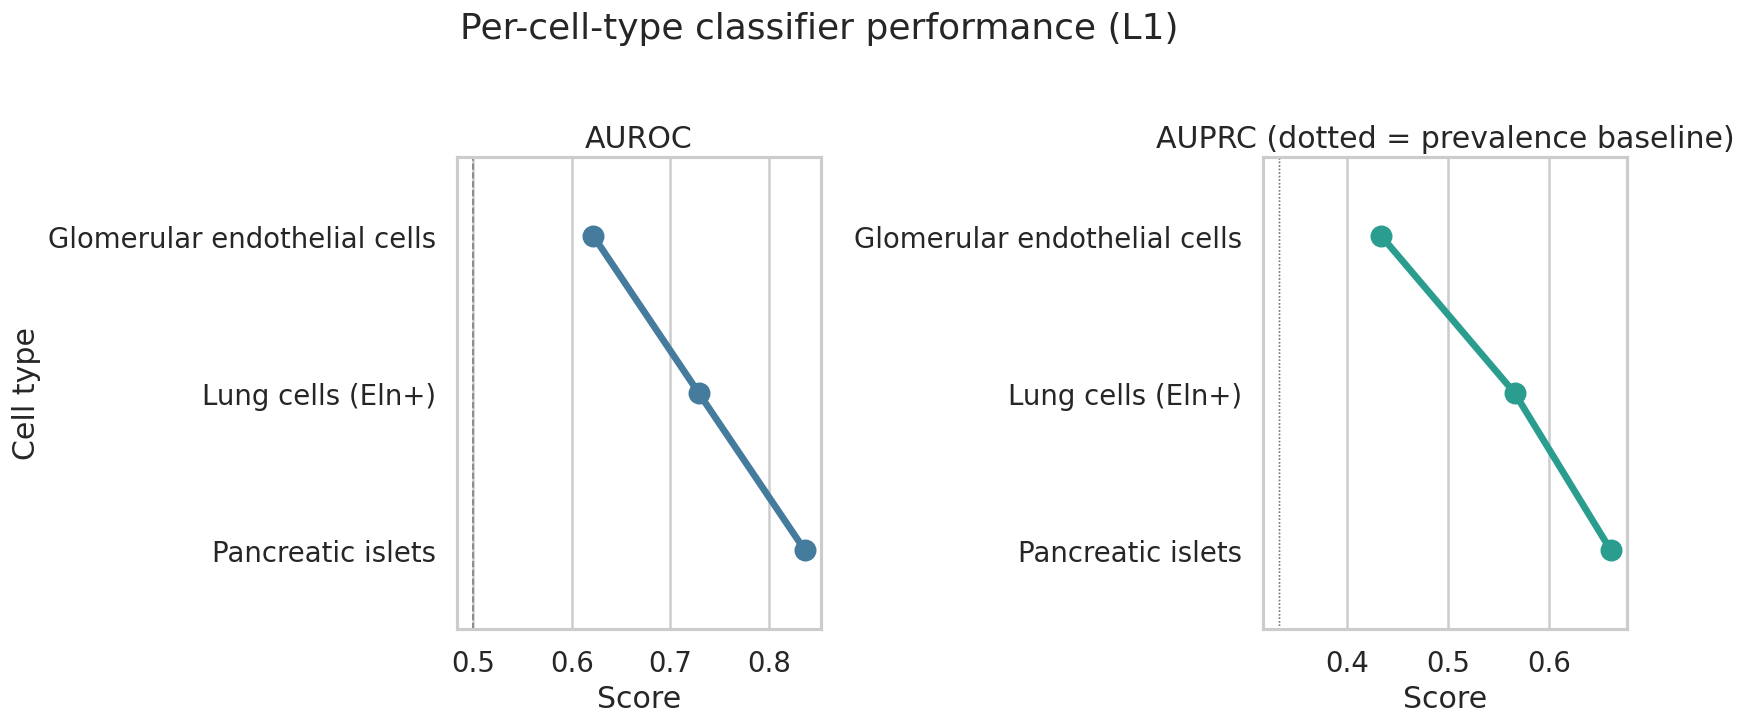

In [17]:
m_long = model_metrics.melt(
    id_vars=["celltype_update", "baseline_prevalence"],
    value_vars=["auroc", "auprc"],
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

sns.pointplot(data=m_long[m_long["metric"] == "auroc"], y="celltype_update", x="value", color="#457b9d", ax=axes[0])
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("AUROC")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Cell type")

sns.pointplot(data=m_long[m_long["metric"] == "auprc"], y="celltype_update", x="value", color="#2a9d8f", ax=axes[1])
for _, row in model_metrics.iterrows():
    axes[1].axvline(row["baseline_prevalence"], color="gray", linestyle=":", linewidth=0.8)
axes[1].set_title("AUPRC (dotted = prevalence baseline)")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("")

fig.suptitle("Per-cell-type classifier performance (L1)", y=1.02)
plt.tight_layout()
save_fig(fig, "Fig3_model_performance")
plt.show()


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig4_coef_heatmap.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig4_coef_heatmap.svg


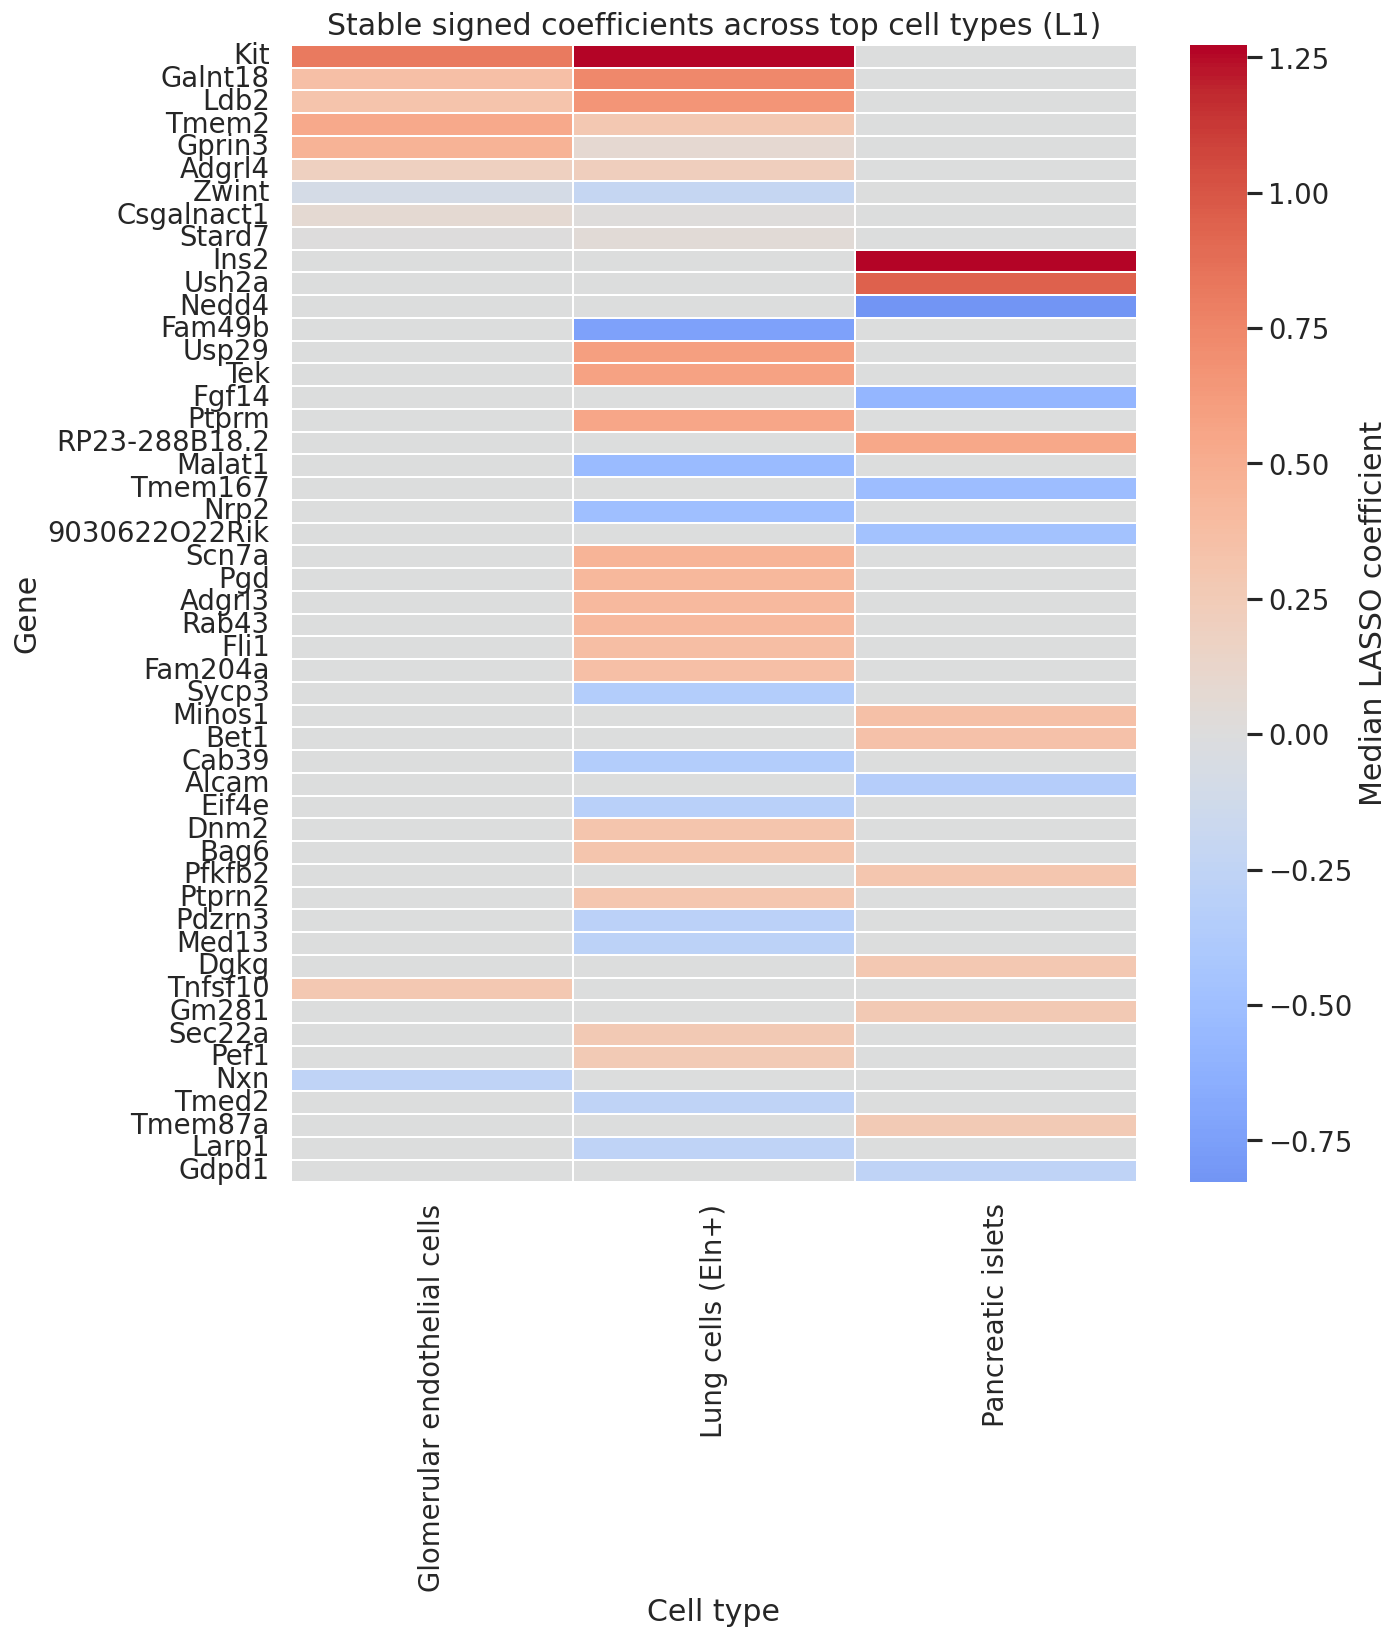

In [18]:
gene_sharedness = stable_coef.groupby("gene")["celltype_update"].nunique().rename("n_celltypes")
gene_strength = stable_coef.groupby("gene")["abs_coef"].mean().rename("mean_abs_coef")
gene_rank = pd.concat([gene_sharedness, gene_strength], axis=1).sort_values(
    ["n_celltypes", "mean_abs_coef"],
    ascending=[False, False]
)
top_genes = gene_rank.head(50).index

heat = (
    stable_coef[stable_coef["gene"].isin(top_genes)]
    .pivot_table(index="gene", columns="celltype_update", values="coef_median", fill_value=0.0)
)
row_order = gene_rank.loc[heat.index].sort_values(
    ["n_celltypes", "mean_abs_coef"],
    ascending=[False, False]
).index
heat = heat.loc[row_order]

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    heat,
    cmap="coolwarm",
    center=0,
    linewidths=0.1,
    linecolor="white",
    yticklabels=1,
    cbar_kws={"label": "Median LASSO coefficient"},
    ax=ax
)
ax.set_title("Stable signed coefficients across top cell types (L1)")
ax.set_xlabel("Cell type")
ax.set_ylabel("Gene")

plt.tight_layout()
save_fig(fig, "Fig4_coef_heatmap")
plt.show()


/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original

Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig5_overlap_upset_jaccard.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig5_overlap_upset_jaccard.svg


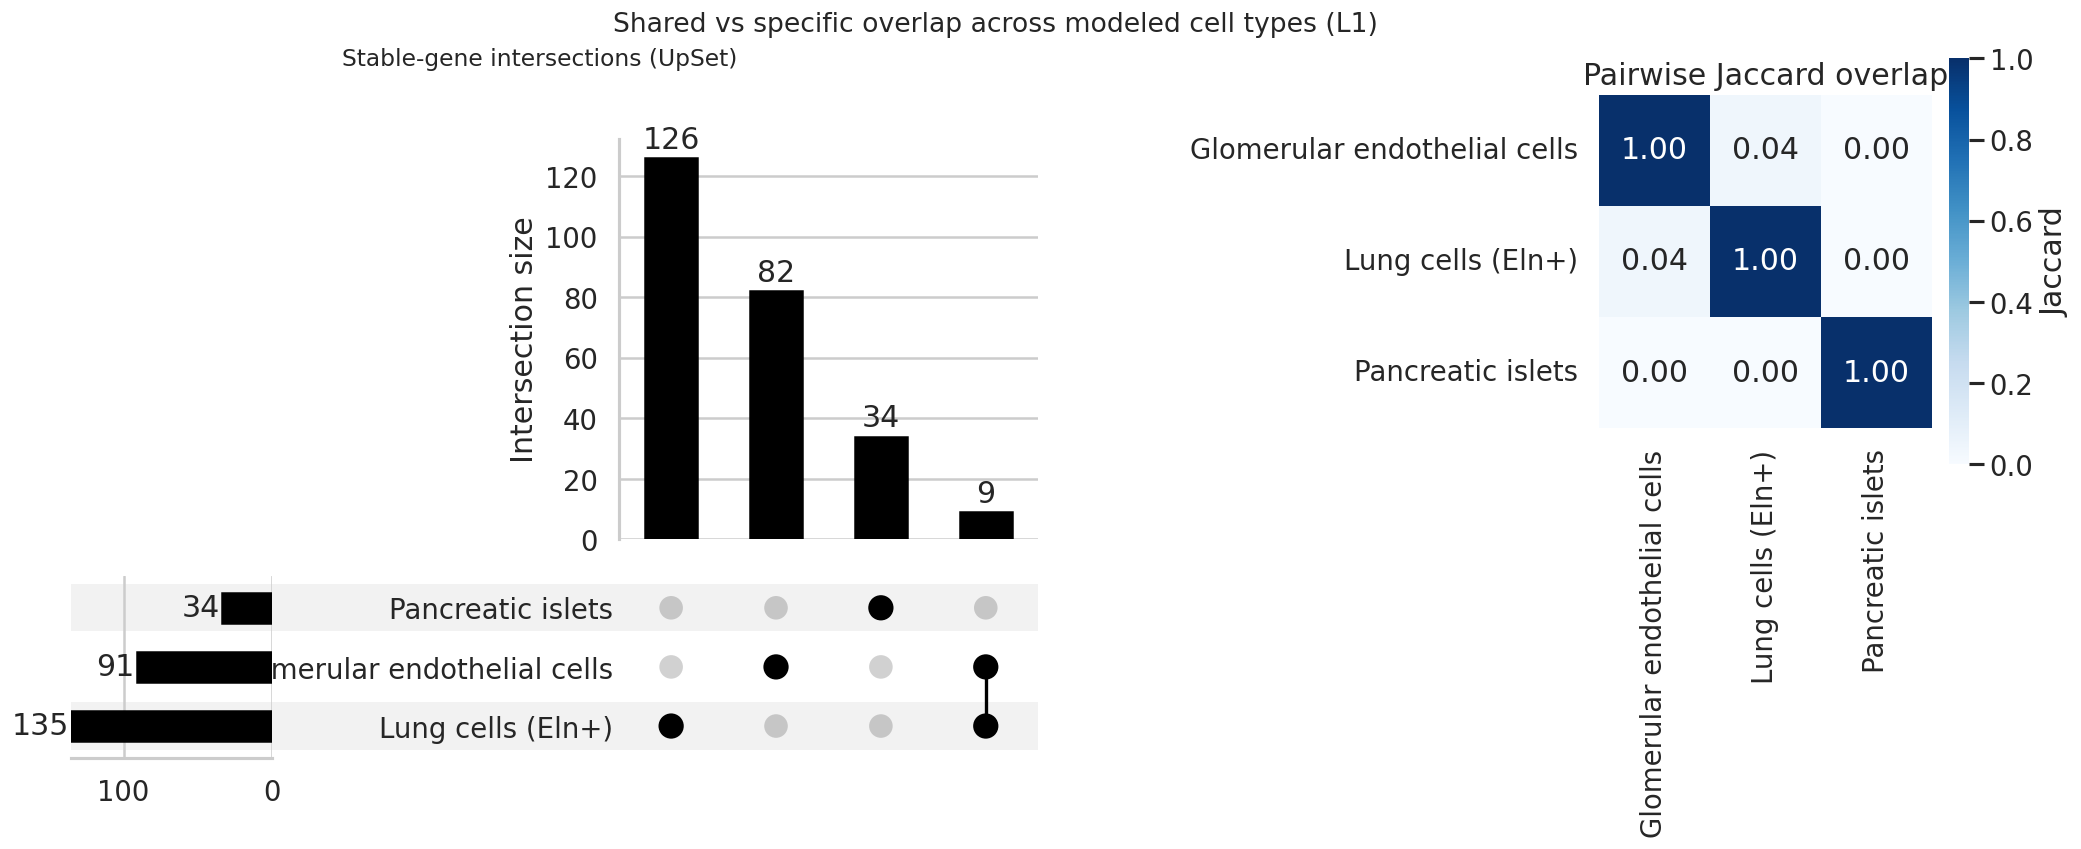

In [19]:
contents = {
    ct: set(stable_coef.loc[stable_coef["celltype_update"] == ct, "gene"].astype(str))
    for ct in selected_ct
}
upset_data = from_contents(contents)

jmat = pairwise_jaccard.pivot(index="celltype_a", columns="celltype_b", values="jaccard").loc[selected_ct, selected_ct]

fig = plt.figure(figsize=(18, 7), constrained_layout=True)
subfigs = fig.subfigures(1, 2, width_ratios=[1.4, 1.0])

upset = UpSet(upset_data, show_counts=True, sort_by="cardinality", element_size=None)
upset.plot(fig=subfigs[0])
subfigs[0].suptitle("Stable-gene intersections (UpSet)", fontsize=14)

ax = subfigs[1].subplots(1, 1)
sns.heatmap(
    jmat,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Jaccard"},
    ax=ax
)
ax.set_title("Pairwise Jaccard overlap")
ax.set_xlabel("")
ax.set_ylabel("")

fig.suptitle("Shared vs specific overlap across modeled cell types (L1)", fontsize=16)
save_fig(fig, "Fig5_overlap_upset_jaccard")
plt.show()


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig6_shared_specific_summary.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig6_shared_specific_summary.svg


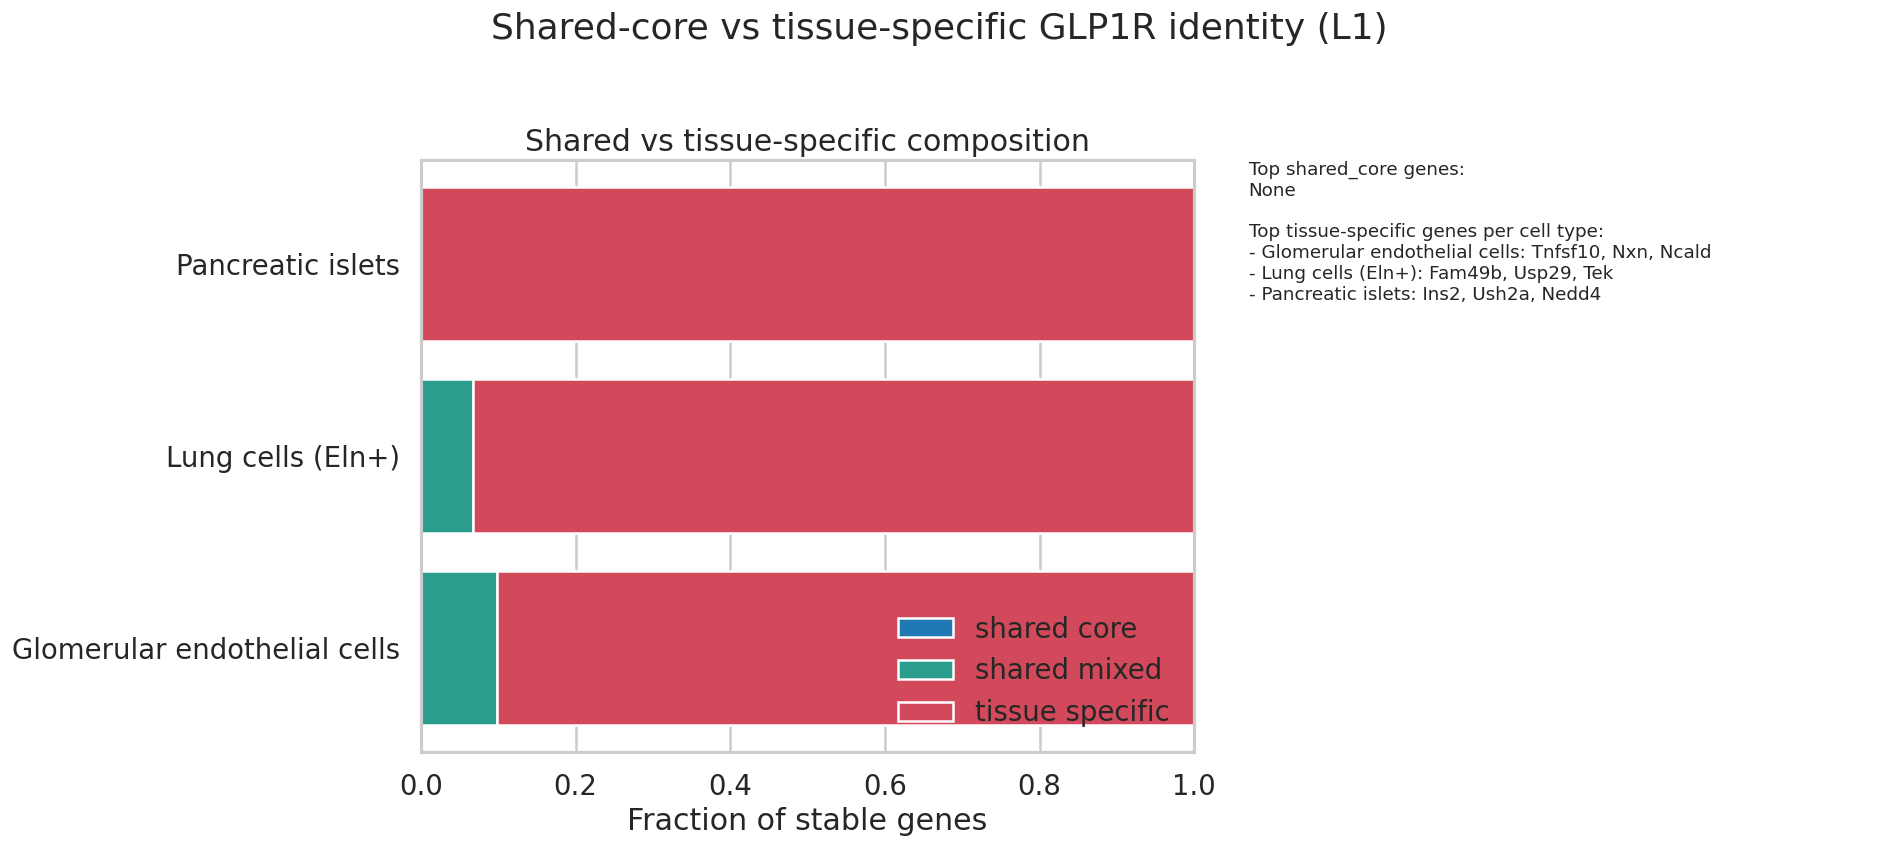

In [20]:
class_map = shared_specific.set_index("gene")["class"]
stable_coef["gene_class"] = stable_coef["gene"].map(class_map).fillna("unclassified")

comp = stable_coef.groupby(["celltype_update", "gene_class"]).size().rename("n_genes").reset_index()
comp["fraction"] = comp["n_genes"]/comp.groupby("celltype_update")["n_genes"].transform("sum")

classes = ["shared_core", "shared_mixed", "tissue_specific"]
color_map = {"shared_core": "#1f77b4",
             "shared_mixed": "#2a9d8f",
             "tissue_specific": "#d1495b"}

plot_mat = (comp.pivot(index="celltype_update", columns="gene_class", values="fraction").reindex(index=selected_ct).fillna(0.0))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.25, 1]})

bottom = np.zeros(len(plot_mat))
for gene_class in classes:
    values = plot_mat[gene_class].values if gene_class in plot_mat.columns else np.zeros(len(plot_mat))
    axes[0].barh(plot_mat.index, values, left=bottom, color=color_map[gene_class], label=gene_class.replace("_", " "))
    bottom += values

axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Fraction of stable genes")
axes[0].set_title("Shared vs tissue-specific composition")
axes[0].legend(frameon=False, loc="lower right")

axes[1].axis("off")
shared_top = (
    stable_coef[stable_coef["gene_class"] == "shared_core"]
    .groupby("gene")["abs_coef"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

lines = ["Top shared_core genes:", ", ".join(shared_top) if shared_top else "None", "", "Top tissue-specific genes per cell type:"]
for ct in selected_ct:
    top_ts = (
        stable_coef[
            (stable_coef["celltype_update"] == ct)
            & (stable_coef["gene_class"] == "tissue_specific")
        ]
        .sort_values("abs_coef", ascending=False)
        .head(3)["gene"]
        .tolist()
    )
    lines.append(f"- {ct}: {', '.join(top_ts) if top_ts else 'None'}")

axes[1].text(0.0, 1.0, "\n".join(lines), va="top", ha="left", fontsize=11)

fig.suptitle("Shared-core vs tissue-specific GLP1R identity (L1)", y=1.02)
plt.tight_layout()
save_fig(fig, "Fig6_shared_specific_summary")
plt.show()


## XGBoost benchmark


In [21]:
xgb_metric_summary_rows = []
xgb_metric_repeat_rows = []
xgb_perm_tables = []
xgb_feature_tables = []

for ct in selected_ct:
    print("Modeling:", ct)
    bundle = prepared_data[ct]
    X = bundle["X"]
    y = bundle["y"]
    genes_kept = pd.Index(bundle["genes_kept"]).astype(str)
    expr_diff_sign = np.asarray(bundle["expr_diff_sign"]).ravel()

    metrics_repeat = fit_xgb_repeated(X, y, repeat_seeds, base_params=XGB_BASE_PARAMS)
    metrics_repeat["celltype_update"] = ct
    metrics_repeat["n_pos"] = bundle["n_pos"]
    metrics_repeat["n_neg"] = bundle["n_neg"]
    metrics_repeat["baseline_prevalence"] = bundle["baseline_prevalence"]
    metrics_repeat["n_genes_after_filter"] = bundle["n_genes_after_filter"]
    metrics_repeat["model"] = "xgboost"
    xgb_metric_repeat_rows.append(metrics_repeat)

    xgb_metric_summary_rows.append({"celltype_update": ct,
                                    "baseline_prevalence": bundle["baseline_prevalence"],
                                    "n_pos": bundle["n_pos"],
                                    "n_neg": bundle["n_neg"],
                                    "n_genes_after_filter": bundle["n_genes_after_filter"],
                                    "auroc": float(metrics_repeat["auroc"].mean()),
                                    "auprc": float(metrics_repeat["auprc"].mean()),
                                    "auroc_sd": float(metrics_repeat["auroc"].std(ddof=0)),
                                    "auprc_sd": float(metrics_repeat["auprc"].std(ddof=0)),
                                    "all_repeats_converged": bool(metrics_repeat["converged"].all())})

    _, perm_agg = compute_xgb_permutation_scores(
        X,
        y,
        genes_kept,
        repeat_seeds,
        base_params=XGB_BASE_PARAMS,
        top_k=XGB_TOP_K,
        perm_repeats=PERM_N_REPEATS
    )
    perm_agg["celltype_update"] = ct
    perm_agg["rank"] = perm_agg["perm_importance_median"].rank(method="first", ascending=False).astype(int)
    xgb_perm_tables.append(perm_agg)

    sign_map = pd.Series(expr_diff_sign, index=genes_kept)
    feat = perm_agg.copy()
    feat["expr_diff_sign"] = feat["gene"].map(sign_map).fillna(0.0).astype(float)
    feat["signed_importance"] = feat["perm_importance_median"]*feat["expr_diff_sign"]
    feat["abs_signed_importance"] = feat["signed_importance"].abs()
    feat["direction"] = np.where(
        feat["signed_importance"] > 0,
        "positive",
        np.where(feat["signed_importance"] < 0, "negative", "zero")
    )
    feat["selected_stable"] = feat["selection_freq"] >= STABLE_FREQ_THRESHOLD
    xgb_feature_tables.append(feat)

xgb_model_metrics = pd.DataFrame(xgb_metric_summary_rows)
xgb_model_metrics_repeat = pd.concat(xgb_metric_repeat_rows, axis=0, ignore_index=True)
xgb_permutation_importance = pd.concat(xgb_perm_tables, axis=0, ignore_index=True)
xgb_feature_scores = pd.concat(xgb_feature_tables, axis=0, ignore_index=True)

xgb_model_metrics.to_csv(RESULTS_DIR/"xgb_model_metrics.csv", index=False)
xgb_model_metrics_repeat.to_csv(RESULTS_DIR/"xgb_model_metrics_repeats.csv", index=False)
xgb_permutation_importance.to_csv(RESULTS_DIR/"xgb_permutation_importance.csv", index=False)
xgb_feature_scores.to_csv(RESULTS_DIR/"xgb_feature_scores.csv", index=False)

print("Saved:", RESULTS_DIR/"xgb_model_metrics.csv")
print("Saved:", RESULTS_DIR/"xgb_model_metrics_repeats.csv")
print("Saved:", RESULTS_DIR/"xgb_permutation_importance.csv")
print("Saved:", RESULTS_DIR/"xgb_feature_scores.csv")
display(xgb_model_metrics)


Modeling: Glomerular endothelial cells
Modeling: Lung cells (Eln+)
Modeling: Pancreatic islets
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/xgb_model_metrics.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/xgb_model_metrics_repeats.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/xgb_permutation_importance.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/xgb_feature_scores.csv


,celltype_update,baseline_prevalence,n_pos,n_neg,n_genes_after_filter,auroc,auprc,auroc_sd,auprc_sd,all_repeats_converged
0,Glomerular endothelial cells,0.333333,418,836,11550,0.664785,0.470048,0.003898,0.008636,True
1,Lung cells (Eln+),0.333333,240,480,12535,0.731807,0.556214,0.015279,0.018441,True
2,Pancreatic islets,0.333333,57,114,13240,0.813050,0.608357,0.006641,0.022097,True


In [22]:
lasso_repeat = model_metrics_repeat.copy()
lasso_repeat["model"] = "lasso_l1"

bench_cols = [
    "celltype_update",
    "model",
    "repeat_seed",
    "auroc",
    "auprc",
    "n_pos",
    "n_neg",
    "baseline_prevalence",
    "n_genes_after_filter"
]

benchmark_metrics_repeats = pd.concat(
    [lasso_repeat[bench_cols], xgb_model_metrics_repeat[bench_cols]],
    axis=0,
    ignore_index=True
)
benchmark_metrics_repeats.to_csv(RESULTS_DIR/"benchmark_metrics_repeats.csv", index=False)

benchmark_metrics_summary = (
    benchmark_metrics_repeats.groupby(["celltype_update", "model"], as_index=False)
    .agg(
        auroc=("auroc", "mean"),
        auprc=("auprc", "mean"),
        auroc_sd=("auroc", lambda s: float(np.std(s, ddof=0))),
        auprc_sd=("auprc", lambda s: float(np.std(s, ddof=0))),
        baseline_prevalence=("baseline_prevalence", "mean"),
        n_pos=("n_pos", "max"),
        n_neg=("n_neg", "max"),
        n_genes_after_filter=("n_genes_after_filter", "max")
    )
)
benchmark_metrics_summary.to_csv(RESULTS_DIR/"benchmark_metrics_summary.csv", index=False)

summary_wide = benchmark_metrics_summary.pivot(index="celltype_update", columns="model", values=["auroc", "auprc"])
benchmark_metrics_delta = pd.DataFrame(
    {
        "celltype_update": summary_wide.index,
        "auroc_lasso": summary_wide[("auroc", "lasso_l1")].values,
        "auroc_xgboost": summary_wide[("auroc", "xgboost")].values,
        "auroc_delta_xgb_minus_lasso": (summary_wide[("auroc", "xgboost")] - summary_wide[("auroc", "lasso_l1")]).values,
        "auprc_lasso": summary_wide[("auprc", "lasso_l1")].values,
        "auprc_xgboost": summary_wide[("auprc", "xgboost")].values,
        "auprc_delta_xgb_minus_lasso": (summary_wide[("auprc", "xgboost")] - summary_wide[("auprc", "lasso_l1")]).values
    }
)
benchmark_metrics_delta.to_csv(RESULTS_DIR/"benchmark_metrics_delta_xgb_minus_lasso.csv", index=False)

print("Saved:", RESULTS_DIR/"benchmark_metrics_repeats.csv")
print("Saved:", RESULTS_DIR/"benchmark_metrics_summary.csv")
print("Saved:", RESULTS_DIR/"benchmark_metrics_delta_xgb_minus_lasso.csv")

display(benchmark_metrics_summary.sort_values(["celltype_update", "model"]))
display(benchmark_metrics_delta)


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/benchmark_metrics_repeats.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/benchmark_metrics_summary.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/benchmark_metrics_delta_xgb_minus_lasso.csv


,celltype_update,model,auroc,auprc,auroc_sd,auprc_sd,baseline_prevalence,n_pos,n_neg,n_genes_after_filter
0,Glomerular endothelial cells,lasso_l1,0.621801,0.433896,0.010258,0.008701,0.333333,418,836,11550
1,Glomerular endothelial cells,xgboost,0.664785,0.470048,0.003898,0.008636,0.333333,418,836,11550
2,Lung cells (Eln+),lasso_l1,0.728826,0.565600,0.018075,0.026108,0.333333,240,480,12535
3,Lung cells (Eln+),xgboost,0.731807,0.556214,0.015279,0.018441,0.333333,240,480,12535
4,Pancreatic islets,lasso_l1,0.836442,0.660404,0.005645,0.022533,0.333333,57,114,13240
5,Pancreatic islets,xgboost,0.813050,0.608357,0.006641,0.022097,0.333333,57,114,13240


,celltype_update,auroc_lasso,auroc_xgboost,auroc_delta_xgb_minus_lasso,auprc_lasso,auprc_xgboost,auprc_delta_xgb_minus_lasso
0,Glomerular endothelial cells,0.621801,0.664785,0.042984,0.433896,0.470048,0.036152
1,Lung cells (Eln+),0.728826,0.731807,0.002981,0.565600,0.556214,-0.009386
2,Pancreatic islets,0.836442,0.813050,-0.023392,0.660404,0.608357,-0.052048


In [23]:
xgb_stable = xgb_feature_scores[
    (xgb_feature_scores["selected_stable"]) & (xgb_feature_scores["signed_importance"] != 0)
].copy()

xgb_shared_specific_rows = []
for gene, group in xgb_stable.groupby("gene"):
    n_celltypes = group["celltype_update"].nunique()
    nonzero_signs = set(np.sign(group["signed_importance"].values))
    nonzero_signs.discard(0)

    if n_celltypes == 1:
        label = "tissue_specific"
    elif n_celltypes >= 3 and len(nonzero_signs) == 1:
        label = "shared_core"
    else:
        label = "shared_mixed"

    xgb_shared_specific_rows.append({"gene": str(gene),
                                     "n_celltypes_selected": int(n_celltypes),
                                     "class": label,
                                     "celltypes": ";".join(sorted(group["celltype_update"].astype(str).unique())),
                                     "mean_abs_signed_importance": float(group["abs_signed_importance"].mean())})
xgb_shared_specific = pd.DataFrame(xgb_shared_specific_rows)

gene_sets = {
    ct: set(xgb_stable.loc[xgb_stable["celltype_update"] == ct, "gene"].astype(str))
    for ct in selected_ct
}
xgb_pairwise_jaccard_rows = []
for celltype_a, celltype_b in itertools.product(selected_ct, selected_ct):
    genes_a = gene_sets[celltype_a]
    genes_b = gene_sets[celltype_b]
    union = len(genes_a | genes_b)
    xgb_pairwise_jaccard_rows.append({"celltype_a": celltype_a,
                                      "celltype_b": celltype_b,
                                      "jaccard": (len(genes_a & genes_b)/union) if union else np.nan})
xgb_pairwise_jaccard = pd.DataFrame(xgb_pairwise_jaccard_rows)

xgb_shared_specific.to_csv(RESULTS_DIR/"xgb_shared_specific_summary.csv", index=False)
xgb_pairwise_jaccard.to_csv(RESULTS_DIR/"xgb_pairwise_jaccard.csv", index=False)

print("Saved:", RESULTS_DIR/"xgb_shared_specific_summary.csv")
print("Saved:", RESULTS_DIR/"xgb_pairwise_jaccard.csv")
display(xgb_shared_specific.head(10))


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/xgb_shared_specific_summary.csv
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/results/xgb_pairwise_jaccard.csv


,gene,n_celltypes_selected,class,celltypes,mean_abs_signed_importance
0,Adgrl3,1,tissue_specific,Lung cells (Eln+),0.009626
1,Alcam,1,tissue_specific,Pancreatic islets,0.020287
2,Ankrd17,1,tissue_specific,Pancreatic islets,0.000113
3,Auts2,1,tissue_specific,Pancreatic islets,0.000572
4,Bicc1,1,tissue_specific,Lung cells (Eln+),0.004016
5,Carmil1,1,tissue_specific,Pancreatic islets,0.005102
6,Ccdc85a,1,tissue_specific,Lung cells (Eln+),0.003197
7,Cdc42bpa,1,tissue_specific,Pancreatic islets,0.001950
8,Cnot4,1,tissue_specific,Lung cells (Eln+),0.003454
9,Cnot6l,1,tissue_specific,Pancreatic islets,0.002493


## Figures 3-6 (XGBoost)


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig3_xgb_model_performance.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig3_xgb_model_performance.svg


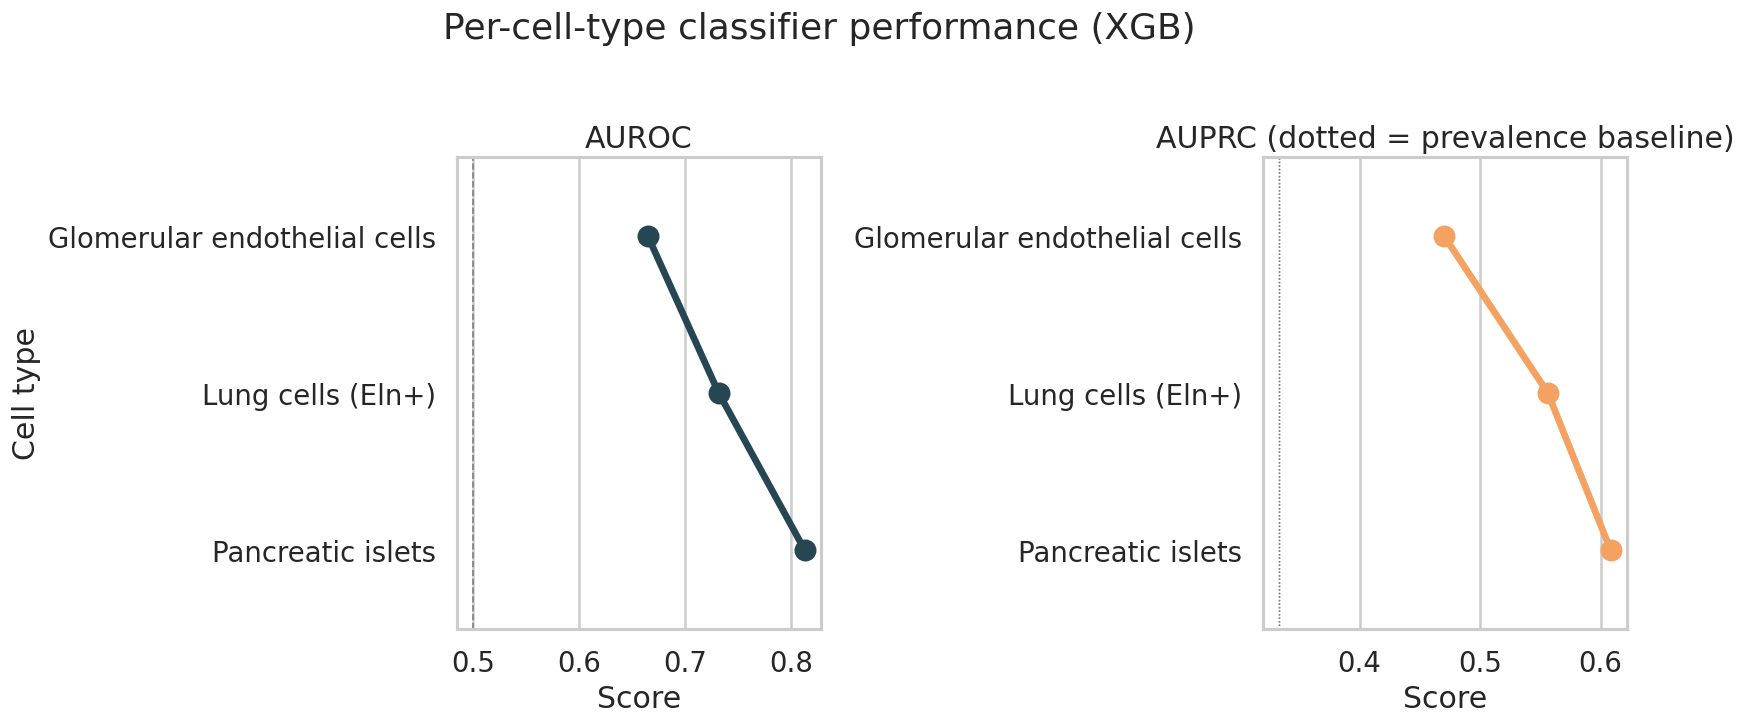

In [24]:
m_long = xgb_model_metrics.melt(
    id_vars=["celltype_update", "baseline_prevalence"],
    value_vars=["auroc", "auprc"],
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

sns.pointplot(data=m_long[m_long["metric"] == "auroc"], y="celltype_update", x="value", color="#264653", ax=axes[0])
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("AUROC")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Cell type")

sns.pointplot(data=m_long[m_long["metric"] == "auprc"], y="celltype_update", x="value", color="#f4a261", ax=axes[1])
for _, row in xgb_model_metrics.iterrows():
    axes[1].axvline(row["baseline_prevalence"], color="gray", linestyle=":", linewidth=0.8)
axes[1].set_title("AUPRC (dotted = prevalence baseline)")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("")

fig.suptitle("Per-cell-type classifier performance (XGB)", y=1.02)
plt.tight_layout()
save_fig(fig, "Fig3_xgb_model_performance")
plt.show()


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig4_xgb_importance_heatmap.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig4_xgb_importance_heatmap.svg


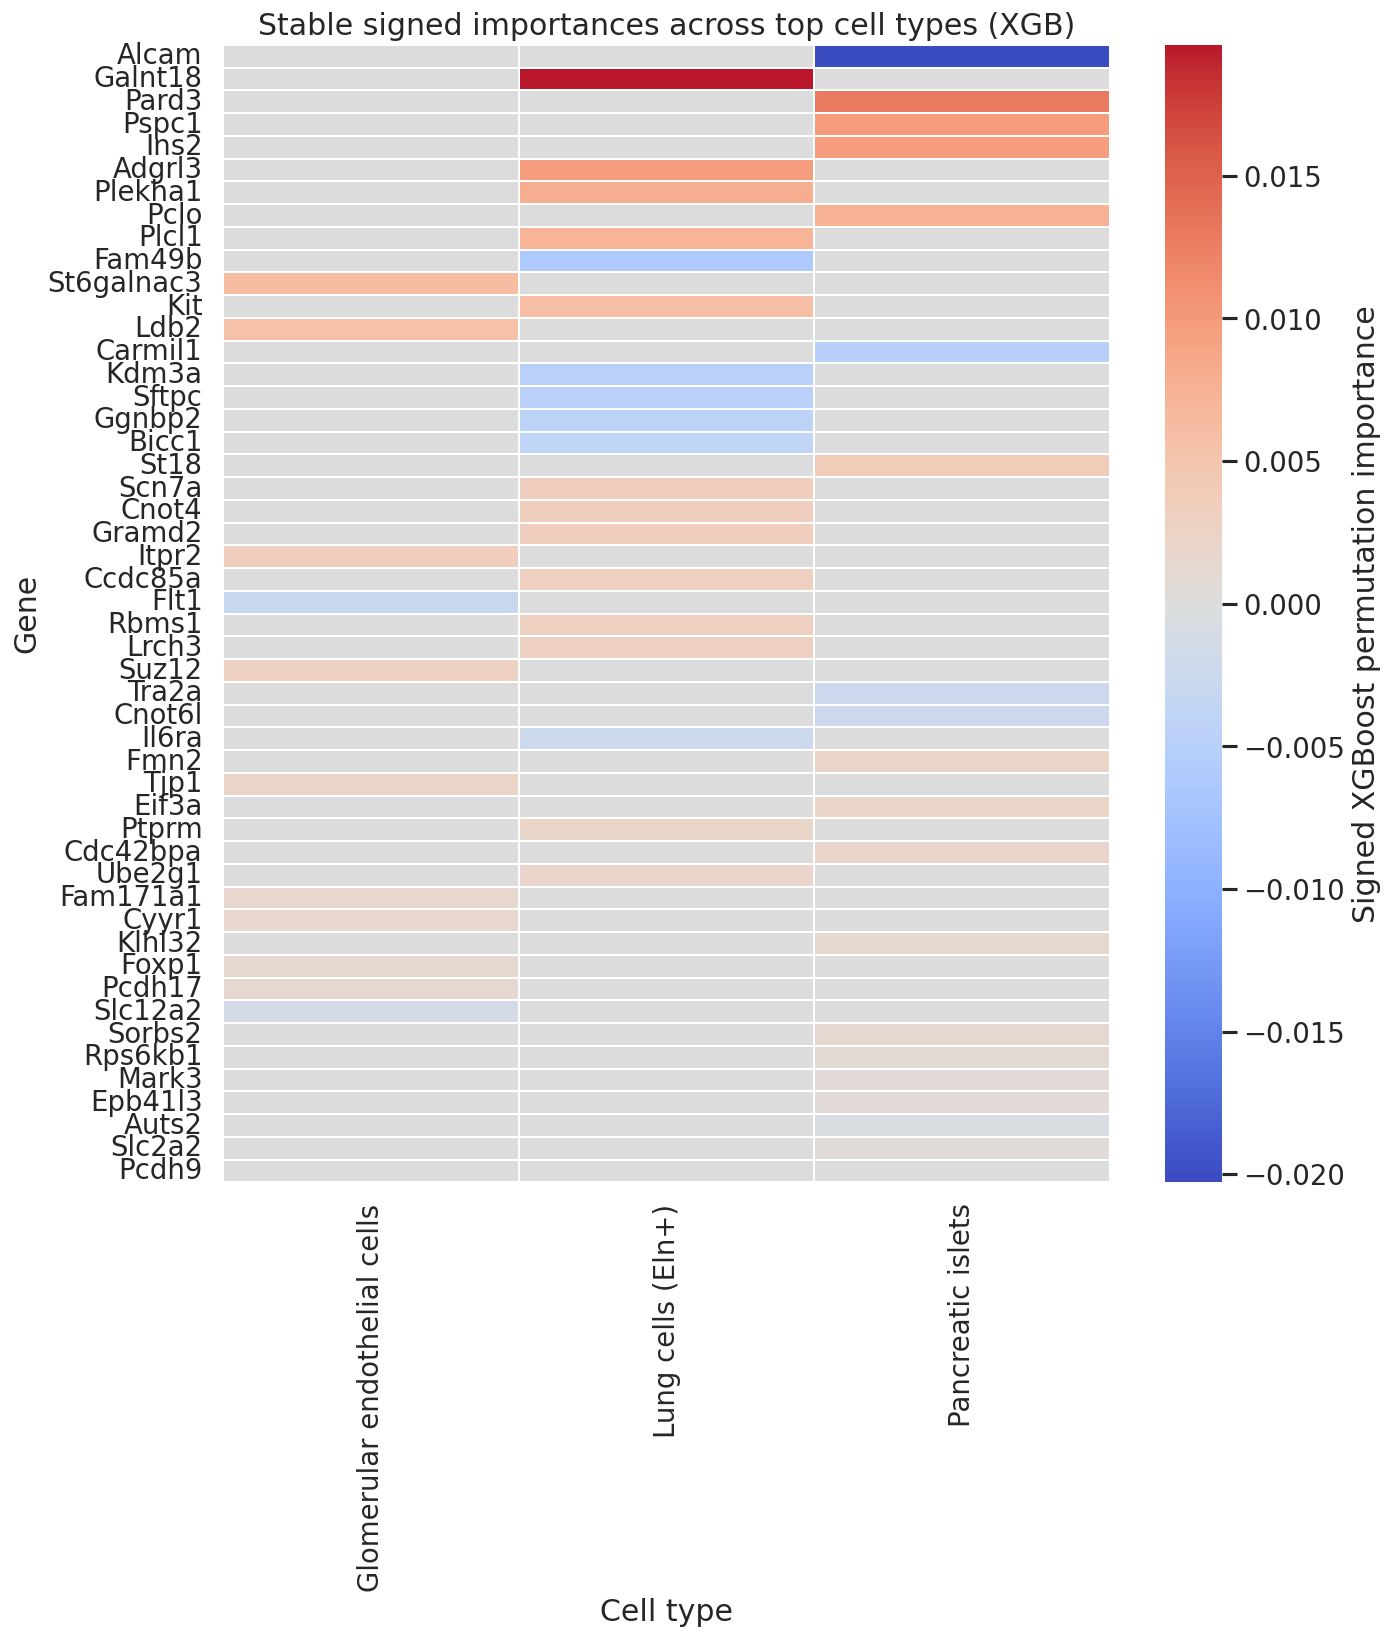

In [25]:
gene_sharedness = xgb_stable.groupby("gene")["celltype_update"].nunique().rename("n_celltypes")
gene_strength = xgb_stable.groupby("gene")["abs_signed_importance"].mean().rename("mean_abs_signed_importance")
gene_rank = pd.concat([gene_sharedness, gene_strength], axis=1).sort_values(
    ["n_celltypes", "mean_abs_signed_importance"],
    ascending=[False, False]
)
top_genes = gene_rank.head(50).index

heat = (
    xgb_stable[xgb_stable["gene"].isin(top_genes)]
    .pivot_table(index="gene", columns="celltype_update", values="signed_importance", fill_value=0.0)
)
row_order = gene_rank.loc[heat.index].sort_values(
    ["n_celltypes", "mean_abs_signed_importance"],
    ascending=[False, False]
).index
heat = heat.loc[row_order]

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(
    heat,
    cmap="coolwarm",
    center=0,
    linewidths=0.1,
    linecolor="white",
    yticklabels=1,
    cbar_kws={"label": "Signed XGBoost permutation importance"},
    ax=ax
)
ax.set_title("Stable signed importances across top cell types (XGB)")
ax.set_xlabel("Cell type")
ax.set_ylabel("Gene")

plt.tight_layout()
save_fig(fig, "Fig4_xgb_importance_heatmap")
plt.show()


/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/ryannayebi/miniforge3/envs/ipynb_python/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original

Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig5_xgb_overlap_upset_jaccard.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig5_xgb_overlap_upset_jaccard.svg


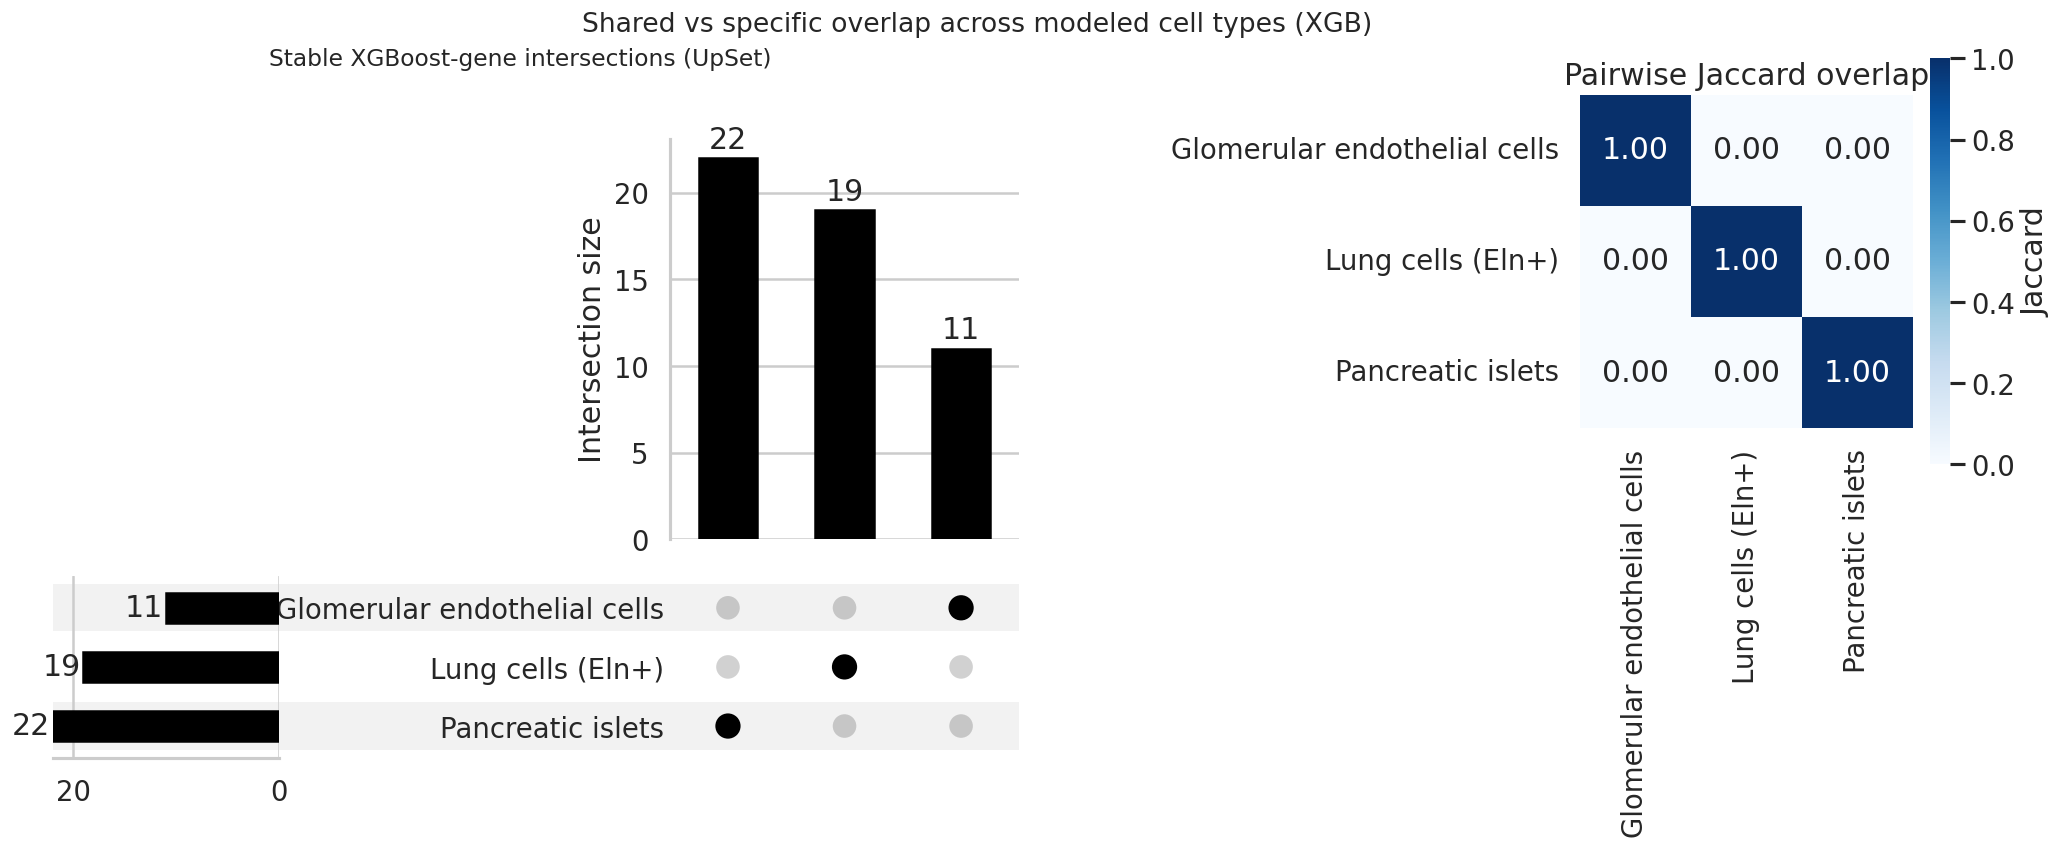

In [ ]:
contents = {
    ct: set(xgb_stable.loc[xgb_stable["celltype_update"] == ct, "gene"].astype(str))
    for ct in selected_ct
}
upset_data = from_contents(contents)

jmat = xgb_pairwise_jaccard.pivot(index="celltype_a", columns="celltype_b", values="jaccard").loc[selected_ct, selected_ct]

fig = plt.figure(figsize=(18, 7), constrained_layout=True)
subfigs = fig.subfigures(1, 2, width_ratios=[1.4, 1.0])

upset = UpSet(upset_data, show_counts=True, sort_by="cardinality", element_size=None)
upset.plot(fig=subfigs[0])
subfigs[0].suptitle("Stable XGBoost-gene intersections (UpSet)", fontsize=14)

ax = subfigs[1].subplots(1, 1)
sns.heatmap(
    jmat,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Jaccard"},
    ax=ax
)
ax.set_title("Pairwise Jaccard overlap")

fig.suptitle("Shared vs specific overlap across modeled cell types (XGB)", fontsize=16)
save_fig(fig, "Fig5_xgb_overlap_upset_jaccard")
plt.show()


Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig6_xgb_shared_specific_summary.png
Saved: /Users/ryannayebi/Downloads/STANFORD/win25/BMDS205/205_proj/nature_proj/analysis/figures/Fig6_xgb_shared_specific_summary.svg


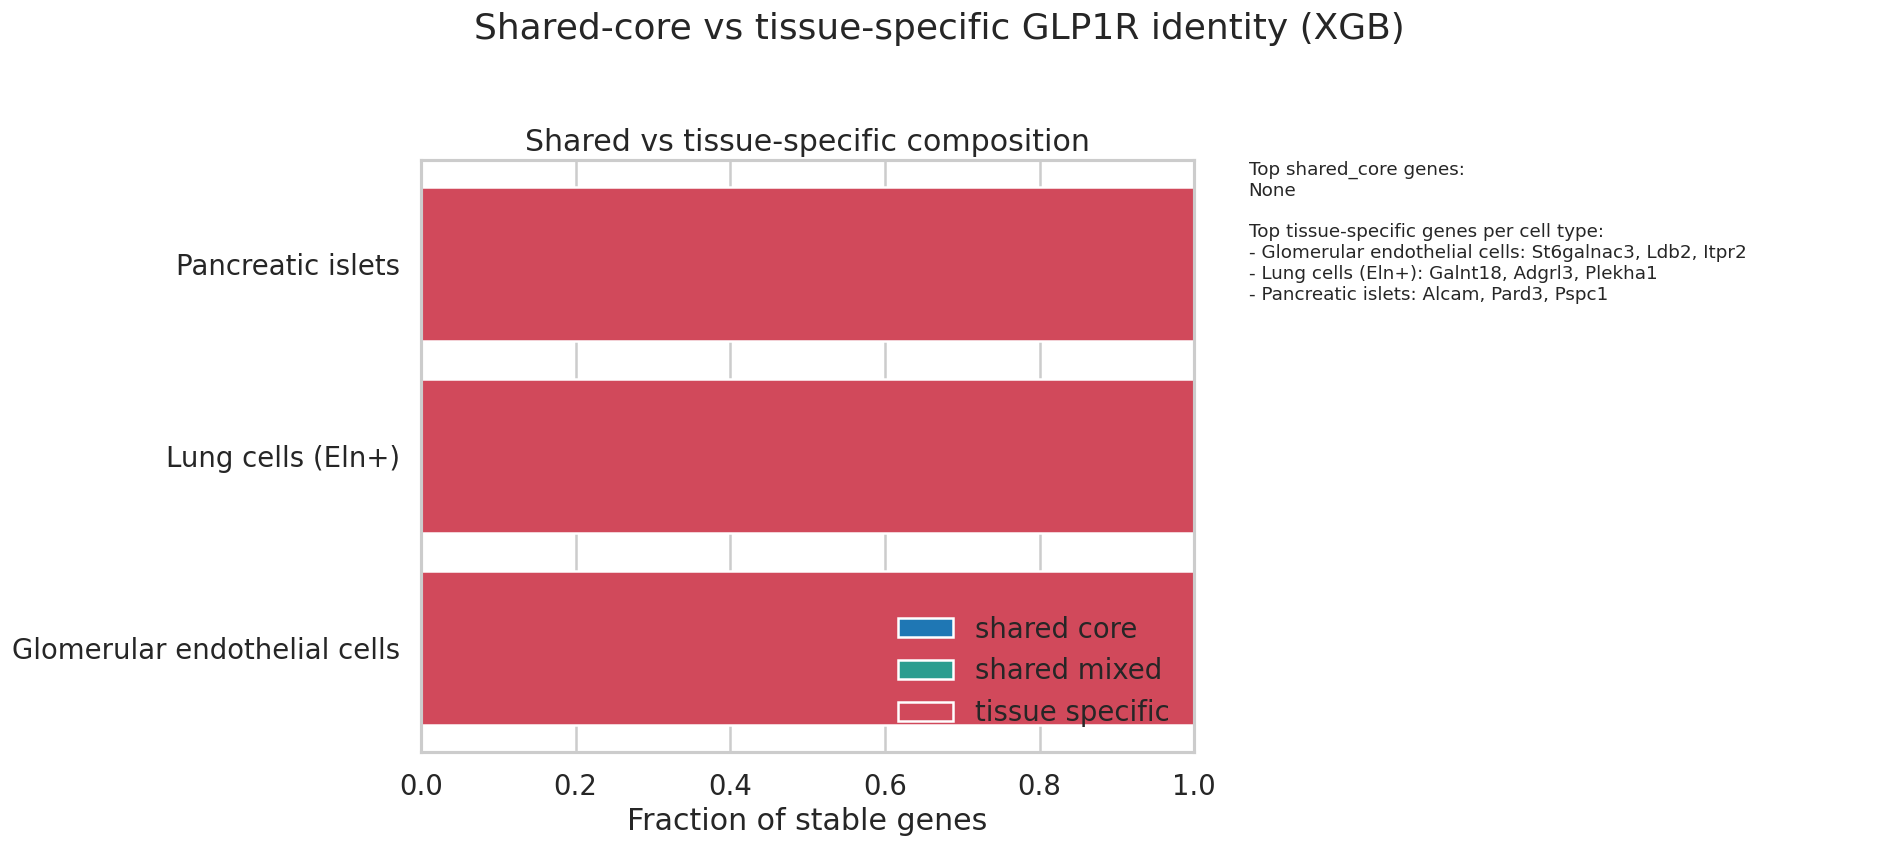

In [27]:
class_map = xgb_shared_specific.set_index("gene")["class"]
xgb_stable["gene_class"] = xgb_stable["gene"].map(class_map).fillna("unclassified")

comp = xgb_stable.groupby(["celltype_update", "gene_class"]).size().rename("n_genes").reset_index()
comp["fraction"] = comp["n_genes"]/comp.groupby("celltype_update")["n_genes"].transform("sum")

classes = ["shared_core", "shared_mixed", "tissue_specific"]
color_map = {
    "shared_core": "#1f77b4",
    "shared_mixed": "#2a9d8f",
    "tissue_specific": "#d1495b"
}

plot_mat = (
    comp.pivot(index="celltype_update", columns="gene_class", values="fraction")
    .reindex(index=selected_ct)
    .fillna(0.0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.25, 1]})

bottom = np.zeros(len(plot_mat))
for gene_class in classes:
    values = plot_mat[gene_class].values if gene_class in plot_mat.columns else np.zeros(len(plot_mat))
    axes[0].barh(plot_mat.index, values, left=bottom, color=color_map[gene_class], label=gene_class.replace("_", " "))
    bottom += values

axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Fraction of stable genes")
axes[0].set_title("Shared vs tissue-specific composition")
axes[0].legend(frameon=False, loc="lower right")

axes[1].axis("off")
shared_top = (
    xgb_stable[xgb_stable["gene_class"] == "shared_core"]
    .groupby("gene")["abs_signed_importance"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

lines = ["Top shared_core genes:", ", ".join(shared_top) if shared_top else "None", "", "Top tissue-specific genes per cell type:"]
for ct in selected_ct:
    top_ts = (
        xgb_stable[
            (xgb_stable["celltype_update"] == ct)
            & (xgb_stable["gene_class"] == "tissue_specific")
        ]
        .sort_values("abs_signed_importance", ascending=False)
        .head(3)["gene"]
        .tolist()
    )
    lines.append(f"- {ct}: {', '.join(top_ts) if top_ts else 'None'}")

axes[1].text(0.0, 1.0, "\n".join(lines), va="top", ha="left", fontsize=11)

fig.suptitle("Shared-core vs tissue-specific GLP1R identity (XGB)", y=1.02)
plt.tight_layout()
save_fig(fig, "Fig6_xgb_shared_specific_summary")
plt.show()
